In [1]:
import os
import sys
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd
from PIL import Image
from glob import glob
from tools.fdm.src import fdm3Blom, mfgrid
from tools.etc import color_cycler, logo, descr, pickleto, picklefrom
from tools.analytic.nsec1 import Nsec1
from importlib import reload

print("=== Current Session ===")
print("os.getcwd():", os.getcwd())
print("sys.executable: ", sys.executable)
print("sys.path:")
for p in sys.path:
    print(p)
print("=======================")


NOTEBOOK_NAME = "explore_data.ipynb"
print(f"NOTEBOOK_NAME = '{NOTEBOOK_NAME}'")

# --- project directory namespace
class Dirs:
    def __init__(self):
        self.rws = "/Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/"
        self.home   = os.path.join(self.rws, "src")
        self.images = os.path.normpath(os.path.join(self.home, '../images'))
        self.data   = os.path.normpath(os.path.join(self.home, '../data'))
        self.pb_data = os.path.normpath(os.path.join(self.data, 'peilbuizen'))
        self.pb_imag = os.path.normpath(os.path.join(self.images, 'peilbuizen'))
        
dirs = Dirs()

# --- dtypes for boundary conditions of Fdm3
dtypes = fdm3Blom.Fdm3.dtypes

print("Project directory namespace:")
descr(dirs)


raai_colors = [
    '#1f77b4',  # blue
    '#ff7f0e',  # orange
    '#2ca02c',  # green
    '#d62728',  # red
    '#9467bd',  # purple
    '#8c564b',  # brown
    '#e377c2',  # pink
    '#7f7f7f',  # gray
    '#bcbd22',  # olive
    '#17becf',  # cyan
    '#aec7e8',  # light blue
    '#ffbb78',  # light orange
    '#98df8a',  # light green    
]

leg_colors = [
    "#0000FF",  # blue
    "#FF0000",  # red
    "#00FF00",  # green
    "#000033",  # dark navy
    "#FF00B6",  # magenta
    "#005300",  # dark green
    "#FFD300",  # yellow
    "#009FFF",  # sky blue
    "#9A4D42",  # brown
    "#00FFBE",  # turquoise
    "#783FC1",  # purple
    "#1F9698",  # teal
    "#FFACFD",  # light pink
    "#B1CC71",  # olive
    "#F1085C",  # crimson
    "#FE8F42",  # orange
    "#DD00FF",  # violet
    "#201A01",  # dark brown
    "#720055",  # dark magenta
    "#766C95"   # slate gray
]

def muT_mu10C(temp):
    """Return ratio visc(TC) / visc(10C).
    
    Good approximation (from ChatGPT, 2026)
    """
    return np.exp(-0.0264 * (temp - 10))


loading mfpath.py

os.getcwd(): /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/notebooks
sys.executable =  /Users/Theo/Development/python/mf6_tools/mf6lab/.venv/bin/python
ARGV ['/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/ipykernel_launcher.py', '--f=/Users/Theo/Library/Jupyter/runtime/kernel-v33ce50f18771de83034f9b437b98ba85e72e00e73.json']
sys.path:
/Users/Theo/GRWMODELS/python/tools
./modules/
/Users/Theo/GRWMODELS/python/bootstraps
/Library/Frameworks/Python.framework/Versions/3.13/lib/python313.zip
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/lib-dynload

/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages
__editable__.mf6lab-0.1.finder.__path_hook__
__editable__.tools-0.1.finder.__path_hook__

=== Current Session ===
os.getcwd(): /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/notebooks
sys

In [3]:
class Peilbuizen():
    def __init__(self, workbook_name, sheet_name=None):
        self.data = pd.read_excel(os.path.join(dirs.pb_imag, workbook_name), sheet_name=sheet_name, index_col='name')
        
    def plot(self, ax, **kwargs):
        """Plot all observation well locations at once."""
        ax.plot(self.data['x'], self.data['y'], 'o', **kwargs)
        
    def put_raai_names(self, ax, xoffset=100., verbose=False, **kwargs):
        """Put the piezometer row names to the right of the last in the row + xoffset."""
        rows = np.arange(100, 1500, 100)
        for r1, r2 in zip(rows[:-1], rows[1:]):
            y = pbxy.data.loc[np.logical_and(pbxy.data.index >= r1, pbxy.cases.index < r2), 'y'].mean().round()
            x = pbxy.cases.loc[np.logical_and(pbxy.data.index >= r1, pbxy.data.index < r2), 'x'].values[-1].round() + xoffset
            ax.text(x, y, f'raai{r1/100:.0f}', **kwargs)
            if verbose:
                print(f"raai{r1/100:.0f}, x={x:.0f}, y={y:.0f}") 


# --- Example:
pbxy = Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='pbTauw')

# --- Plot the data (could be on a map).
# fig, ax = plt.subplots(figsize=(8, 12))
# pbxy.plot(ax, mec='r', mfc='none', ms=6)
# pbxy.put_raai_names(ax, ha='left', va='center')
# ax.plot(ARK_center_line_GE[:,0], ARK_center_line_GE[:,1], 'b', label='ARK-hartlijn')
# ax.set_aspect(1)
# 
# plt.show()


In [4]:
def point_line_distance(P, A, B):
    """
    Distance from points P to infinite line through A and B.

    Parameters
    ----------
    P : (..., 2) array_like
        One or more points.
    A, B : (2,) array_like
        Two points defining the line.

    Returns
    -------
    d : ndarray
        Distances.
    """

    P = np.asarray(P)
    A = np.asarray(A)
    B = np.asarray(B)

    AB = B - A
    AP = P - A

    cross = AB[0] * AP[..., 1] - AB[1] * AP[..., 0]

    return np.round(np.abs(cross) / np.linalg.norm(AB), 2), np.sign(cross)




def point_segment_distance(P, A, B):
    P = np.asarray(P)
    A = np.asarray(A)
    B = np.asarray(B)

    AB = B - A
    AP = P - A

    L2 = np.dot(AB, AB)

    t = np.sum(AP * AB, axis=-1) / L2
    t = np.clip(t, 0.0, 1.0)

    Q = A + t[..., None] * AB

    return np.linalg.norm(P - Q, axis=-1)


def point_polyline_distance(P, polyline):
    """
    Distance from points P to a polyline.

    Parameters
    ----------
    P : (..., 2) array
        One or more points.
    polyline : (n, 2) array
        Vertices of the polyline.

    Returns
    -------
    dmin : (...)
        Minimum distance.
    Qmin : (..., 2)
        Closest points on the polyline.
    """

    P = np.asarray(P)
    polyline = np.asarray(polyline)

    dmin = np.inf * np.ones(P.shape[:-1])
    Qmin = np.zeros(P.shape)

    for A, B in zip(polyline[:-1], polyline[1:]):

        AB = B - A
        AP = P - A

        L2 = np.dot(AB, AB)

        t = np.sum(AP * AB, axis=-1) / L2
        t = np.clip(t, 0.0, 1.0)

        Q = A + t[..., None] * AB

        d = np.linalg.norm(P - Q, axis=-1)

        mask = d < dmin

        dmin[mask] = d[mask]
        Qmin[mask] = Q[mask]

    return dmin, Qmin

In [6]:
hartlijn_ARK = np.array([
    [130051., 479494.],
    [130051., 479403.],
    [130058., 479291.],
    [130057., 478773.],
    [130059., 478204.],
    [130062., 477929.],
    [130060., 477296.],
    [130055., 477008.],
    [129934., 476382.],
    [129903., 476242.],
    [129650., 474744.],
    [129499., 473872.],
    [129386., 473219.],
    [129272., 472556.],
    [129131., 471746.],
    [129024., 471122.],
    [128914., 470499.],
    [128849., 470129.],
    [128714., 469312.],
    [128630., 468844.],
    [128550., 468382.],
    [128439., 467731.],
    [128314., 467022.],
    [128226., 466501.],
    [128136., 465900.]])

# Plot the piezometers on the maps to show their positions in context

In [7]:
pbxy = Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='pbTauw')
pxy = np.asarray(pbxy.data.loc[:, ['x', 'y']])

In [8]:
maps = [os.path.basename(p) for p in glob(os.path.join(dirs.pb_imag, 'map*.png'))]
maps

['map_peilgeb_125629_132885_469223_479409.png',
 'map_pb_tauw_Z_126306_130855_466541_473084.png',
 'map_dwarsdsn_Deltares_124941_134986_464597_481509__hart_129736_475371.png',
 'map_pb_tauw_N_127302_131907_472471_479078.png']

# Observation well locations on map

AttributeError: 'Peilbuizen' object has no attribute 'cases'

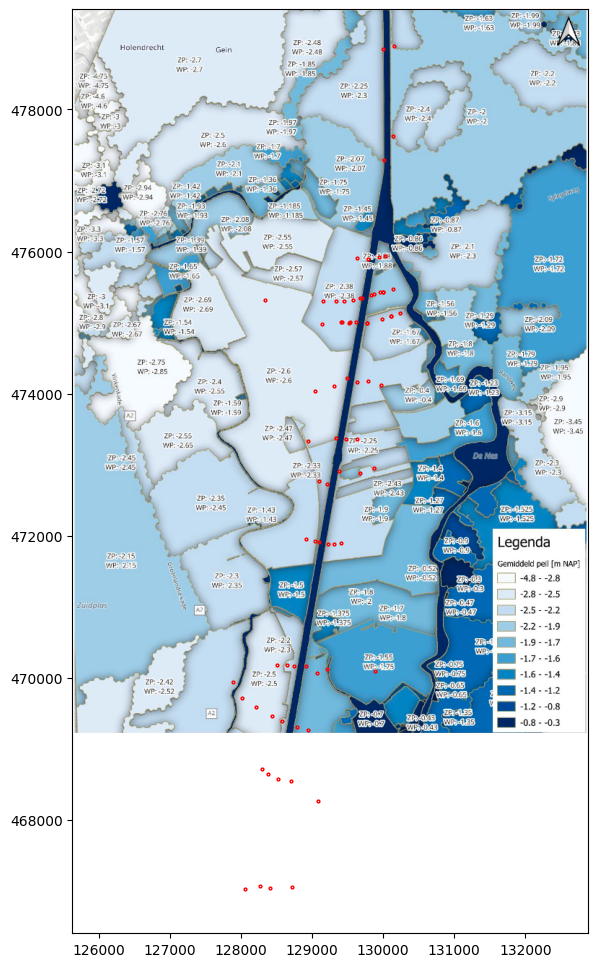

In [9]:

fig, ax = plt.subplots(figsize=(8,12))

im = 0

extent = list(map(float, re.findall(r'\d+', maps[im])))

img = Image.open(os.path.join(dirs.pb_imag, maps[im]))
ax.imshow(img, extent=extent, origin='upper')

pbxy = Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='pbTauw')

pbxy.plot(ax, mec='r', mfc='none', ms=2)
pbxy.put_raai_names(ax, ha='left', va='center')
ax.plot(hartlijn_ARK[:,0], hartlijn_ARK[:,1], 'b', label='ARK-hartlijn')
ax.set_aspect(1)

ax.set_title(f"File: '{maps[im]}'", fontsize=10)
ax.legend()

for pb in pbxy.data.index:
    rec = pbxy.data.loc[pb]
    ax.plot([rec['x'], rec['xhit']], [rec['y'], rec['yhit']], 'k')
    


logo(fig, NOTEBOOK_NAME)
if im == 0:
    fig.savefig(os.path.join(dirs.images, "peilgeb_pb"))
if im == 2:
    fig.savefig(os.path.join(dirs.images, "ligging_dsn_Deltares"))


# Grondwaterstanden

Verkregen webplotdigitizer vanaf de figuren in Deltares rapport "Systeemanalyze, concept maart 2026".

In [ ]:
temp_ark = pd.read_csv(os.path.join(dirs.pb_data, 'tempARK_maarssen.csv'), index_col=0, parse_dates=True)
temp_ark.columns = ['temp']
temp_ark.index.name = 'datetime'
temp_ark

fig, ax = plt.subplots()
ax.plot(temp_ark.index, temp_ark['temp'])
ax.set_ylabel("temperatuur ARK kanaal")
ax.set_title("Temperatuur ARK kanaal in Maarssen")
ax.grid()


# Plot heads en temperatures of all rows (as far as as data is available)

/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a,

pb406, WE=W, dist=   3 m, T_min=12.3, T_max=17.0, t[T_min]=2025-06-28 20:23:59, T[T_max]=2025-12-08 05:28:39
pb407, WE=E, dist=  19 m, T_min=12.0, T_max=19.0, t[T_min]=2025-06-28 05:17:41, T[T_max]=2025-11-09 15:27:40
pb506, WE=W, dist=  28 m, T_min=12.8, T_max=nan, t[T_min]=2025-06-26 23:28:22, T[T_max]=2025-01-17 18:26:53
pb508, WE=E, dist=  24 m, T_min=14.2, T_max=17.4, t[T_min]=2025-11-12 10:00:39, T[T_max]=2025-07-08 20:23:39


/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a,

Month-averaged head around the 3 dates given min, max and min values
pb1,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.322
pb2,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.376
pb3,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.144
pb4,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.403
pb5,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.382
pb6,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.502
pb7,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.489
pb8,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.565
pb9,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.481
pb10,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.559
pb101,2025-01-25,2025-08-01,2026-02-01,nan,-1.692,-1.78
pb102,2025-01-25,2025-08-01,2026-02-01,nan,-1.739,-1.841
pb201,2025-01-25,2025-08-01,2026-02-01,nan,-1.481,-1.684
pb202,2025-01-25,2025-08-01,2026-02-01,nan,-1.49,-1.7
pb301,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.654
pb302,2025-01-25,2025-08-01,2026-02-01,nan,-1.235,-1.556
pb303,2025-01-25,2025-08-01,2026-02-01,nan,-1.116,nan
pb304,2025-01-25,2025

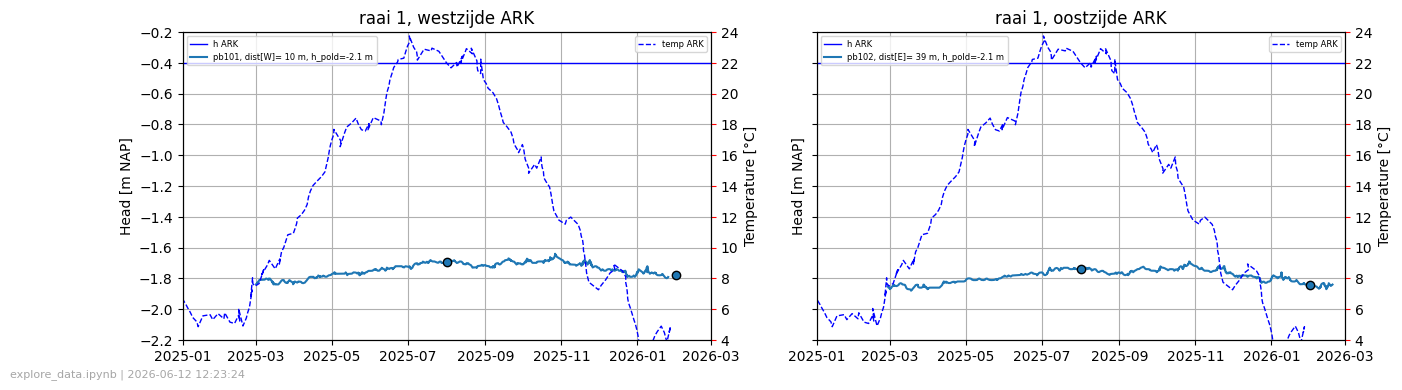

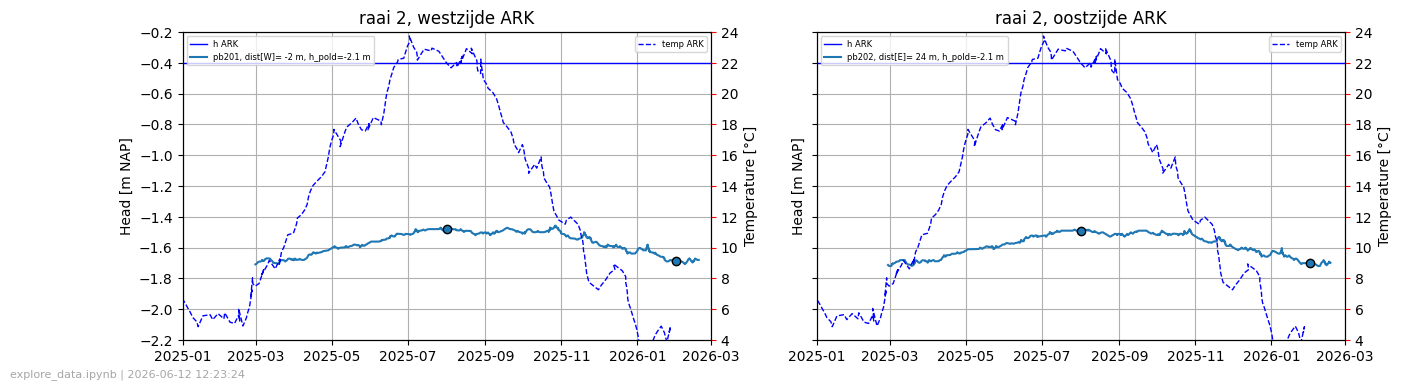

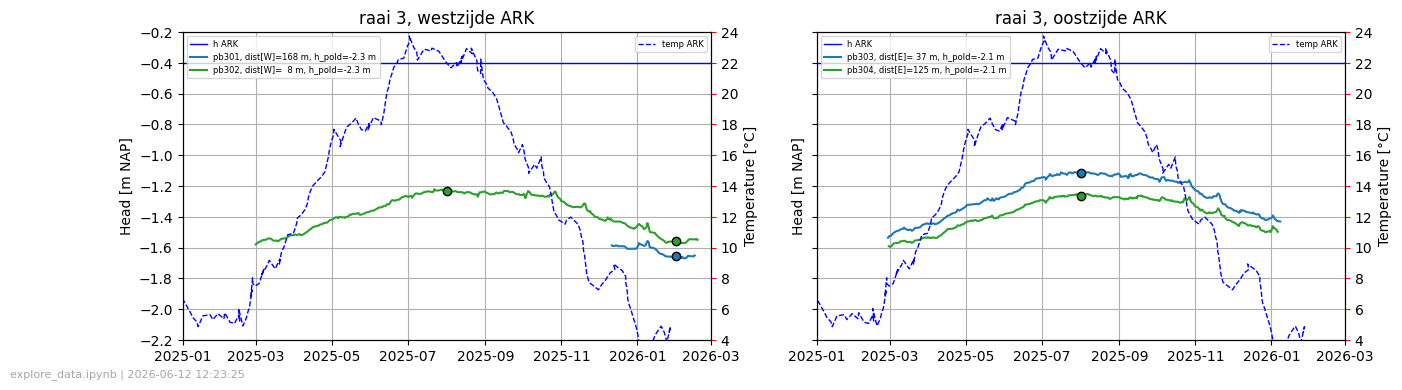

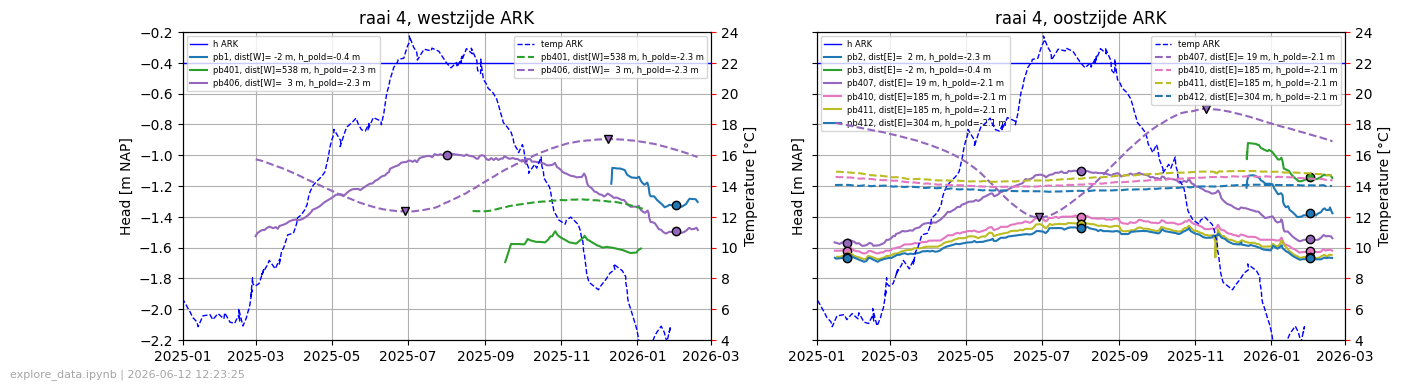

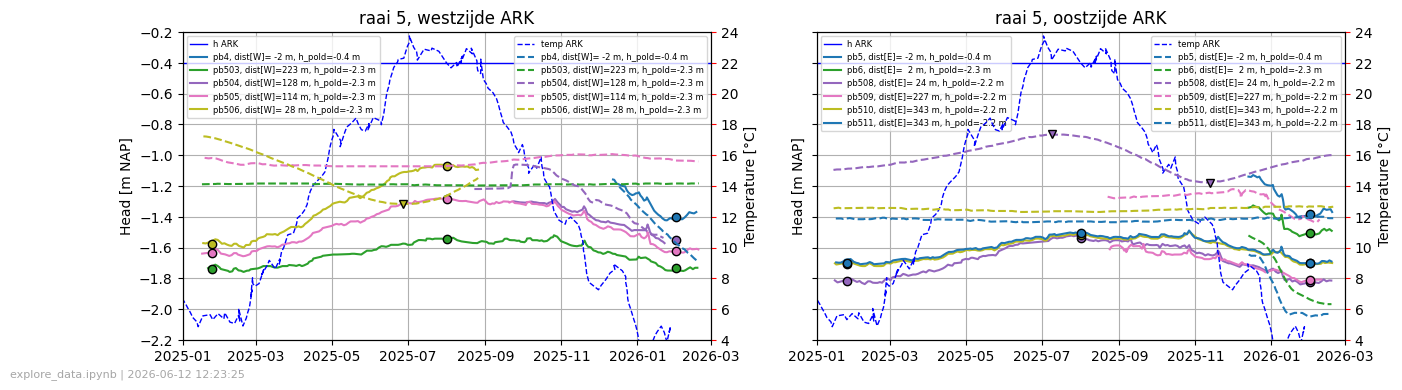

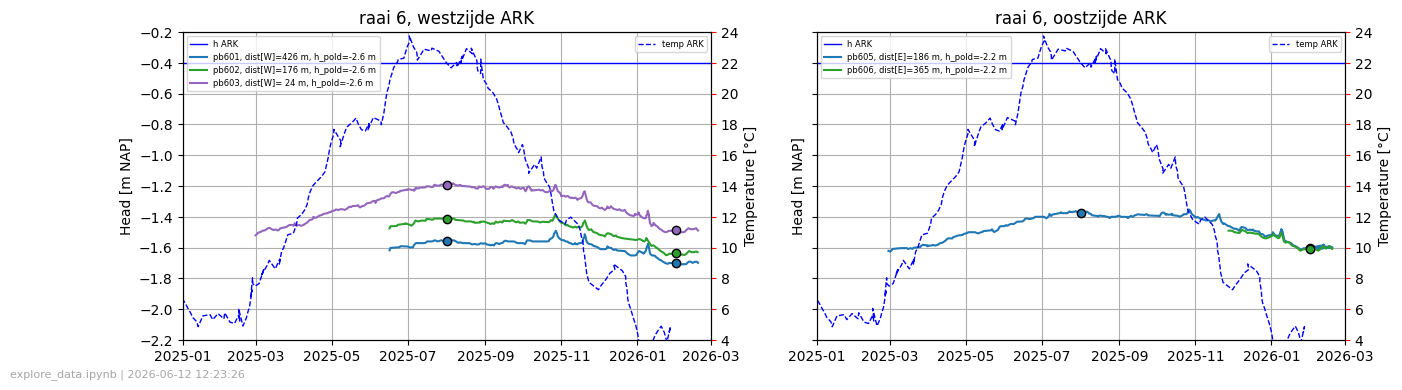

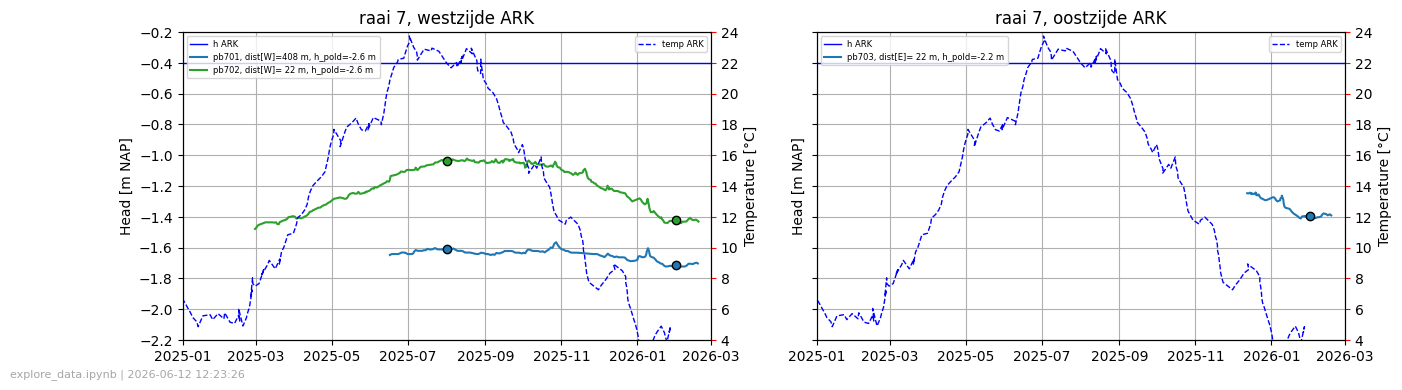

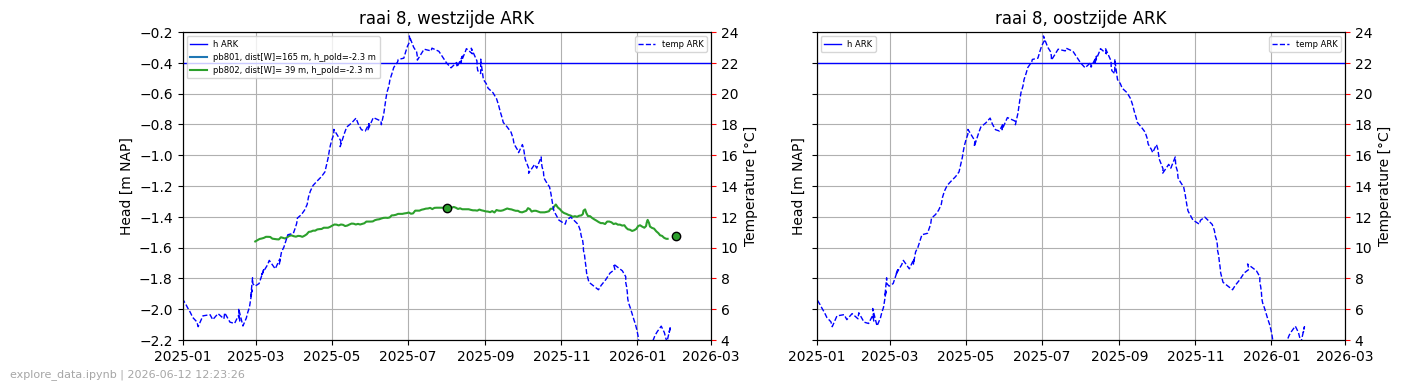

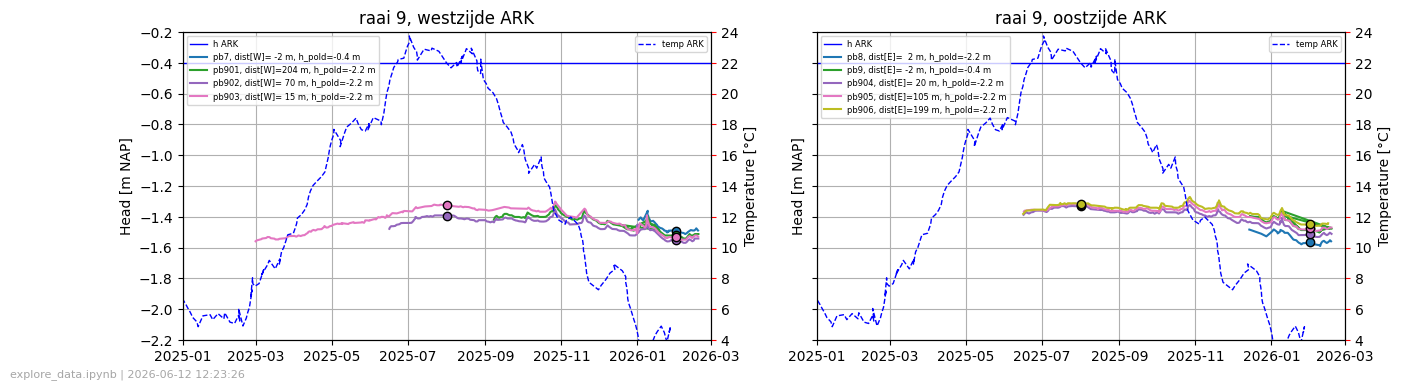

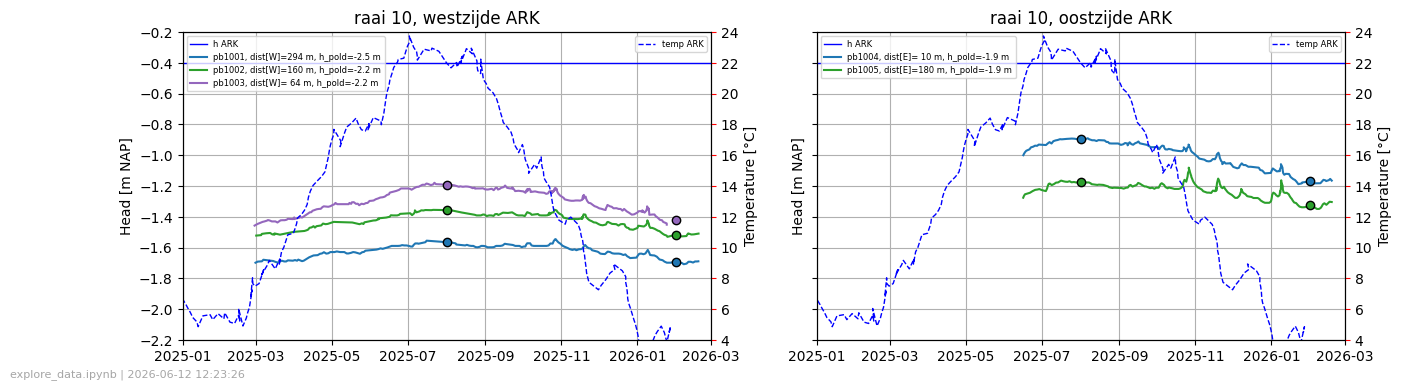

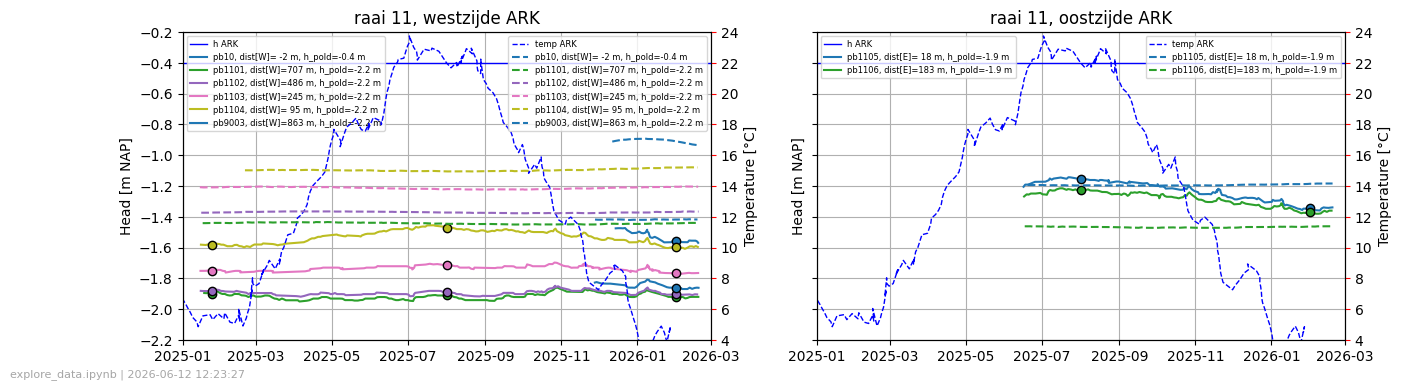

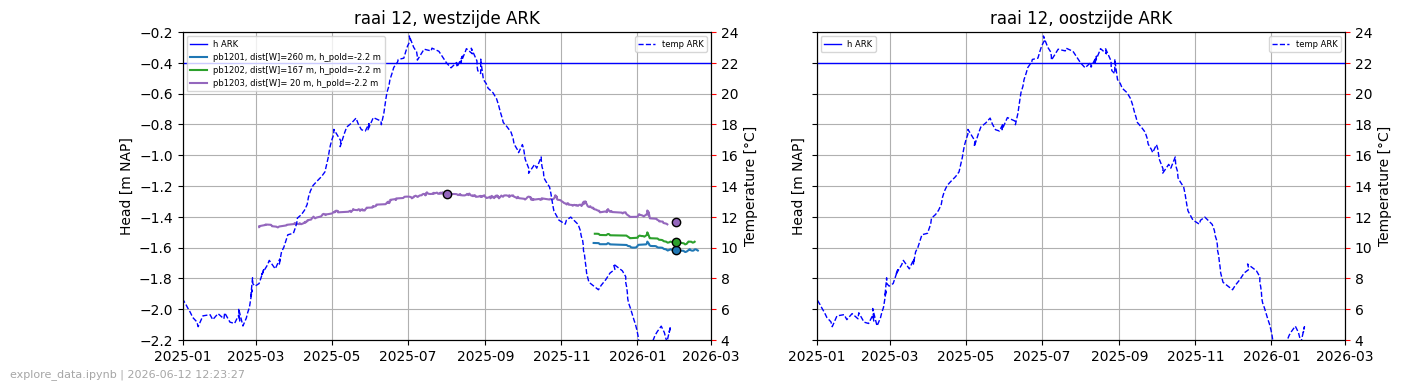

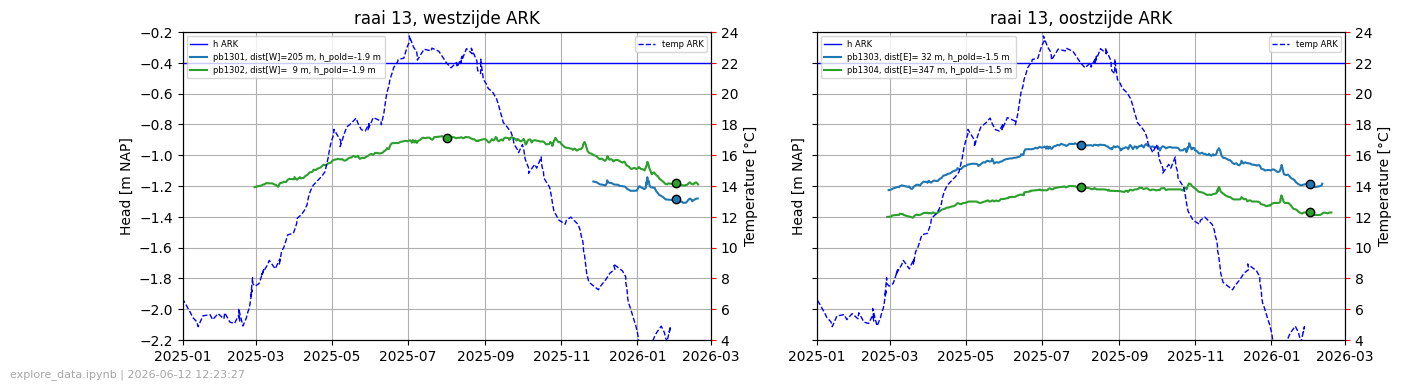

In [5]:
pbxy = Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='pbTauw')
pbkan = Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='pbKanaal')

# --- pd.DataFrame
pb_tauw_meta   = pbxy.data
pb_kanaal_meta = pbkan.data

b_ARK = 50

# --- Get ARK temperature
temp_ark = pd.read_csv(os.path.join(dirs.pb_data, 'tempARK_maarssen.csv'),
                       index_col=0, parse_dates=True)
temp_ark.columns=['temp']
temp_ark.index.name = 'datetime'


# --- Get dictionary with one fig for every row with 2 head and 2 overlapping temp axes
figaxs = {}
for raai in range(1, 14):
    fig, (axW, axE) = plt.subplots(1, 2, figsize=(15, 4), sharex=True, sharey=True)
    
    # logo(fig, NOTEBOOK_NAME)
    
    axW.set_title(f"raai {raai}, westzijde ARK")
    axE.set_title(f"raai {raai}, oostzijde ARK")
        
    xlim = (np.datetime64("2025-01-01"), np.datetime64("2026-03-01"))            
    axW.set_xlim(xlim)
    axE.set_xlim(xlim)
    
    ticks_h    = np.linspace(-2.2, -0.2, 11)
    ticks_temp = np.linspace(4, 24, 11)
    lim_h    = ticks_h[[0, -1]]
    lim_temp = ticks_temp[[0, -1]]
    
    axW.set_ylim(lim_h)
    axE.set_ylim(lim_h)
 
    axWT = axW.twinx()
    axET = axE.twinx()
    
    axET.set_ylabel("temp")
        
    axWT.set_ylim(lim_temp)
    axET.set_ylim(lim_temp)

    axW.set_yticks(ticks_h)
    axE.set_yticks(ticks_h)
    
    axWT.set_yticks(ticks_temp)
    axET.set_yticks(ticks_temp)
    
    axW.grid(True)
    axE.grid(True)
    
    axWT.tick_params(axis='y', color='red')
    axET.tick_params(axis='y', color='red')
    
    axW.set_ylabel('Head [m NAP]')
    axE.set_ylabel('Head [m NAP]')
    axWT.set_ylabel('Temperature [°C]')
    axET.set_ylabel('Temperature [°C]')
    
    h_ARK = -0.4
    axW.plot(xlim, [h_ARK, h_ARK], '-', color='blue', lw=1, label="h ARK") 
    axE.plot(xlim, [h_ARK, h_ARK], '-', color='blue', lw=1, label="h ARK")
    axWT.plot(temp_ark.index, temp_ark.loc[:, 'temp'], '--', color='blue', lw=1, label='temp ARK')
    axET.plot(temp_ark.index, temp_ark.loc[:, 'temp'], '--', color='blue', lw=1, label='temp ARK')

    figaxs[raai] = {'fig': fig, "axW":axW, "axE":axE, "axWT":axWT, "axET":axET}
    
Y = {}

# ---- Get data from these files, determine its row and plot head and temperature on the correct row head and temp axes
for fbn in [ 'pb[0-9].csv', 'pb10.csv', 'pb1[0-9][0-9].csv', 'pb2[0-9][0-9].csv', 'pb3[0-9][0-9].csv', 'pb4[0-9][0-9].csv',
            'pb5[0-9][0-9].csv', 'pb6[0-9][0-9].csv', 'pb7[0-9][0-9].csv', 'pb8[0-9][0-9].csv',
            'pb9[0-9][0-9].csv', 'pb10[0-9][0-9].csv', 'pb11[0-9][0-9].csv',
            'pb12[0-9][0-9].csv', 'pb13[0-9][0-9].csv', 'pb900[0-9].csv']:
    
    # --- current list of csv data files
    pb_csv_files = sorted(glob(os.path.join(dirs.pb_data, fbn)))

    # --- for each piezometer data csv file
    for fname in pb_csv_files:
        basename = os.path.basename(fname)        
        pb_idx = int(re.findall(r"(\d+)", basename)[0])
        pb_name = basename[:-4]
        try:
            # --- Normal drilled piezometer
            rec = pb_tauw_meta.loc[pb_idx]
        except Exception:
            # --- Then a sounding piezometer (not drilled) in or next to the ARK
            rec = pb_kanaal_meta.loc[pb_idx]
          
        # --- Specifics for this piezometer  
        raai = rec['raai']
        dist = rec['dist'] - b_ARK
        WE   = rec['WE']
        VP   = (rec['ZP'] + rec['WP']) / 2
                
        # --- knowing the row of this piezometer, get the correct figure and axes
        fig, axW, axE, axWT, axET = (figaxs[raai]['fig'],
                                     figaxs[raai]['axW'], figaxs[raai]['axE'],
                                     figaxs[raai]['axWT'], figaxs[raai]['axET'])
        
        # --- get the head data
        pb = pd.read_csv(fname, header=None, parse_dates=True, index_col=0)
        pb.columns=['h']
        pb.index.name = 'datetime'
        
        t = pb.index
        y = pb.loc[:, 'h'].values
        
        # --- we want the min and max (average over 1 month around occuring dates)
        mask1 = np.logical_and(t>np.datetime64("2025-01-01"), t < np.datetime64("2025-02-20"))
        mask2 = np.logical_and(t>np.datetime64("2025-07-15"), t < np.datetime64("2025-08-15"))
        mask3 = np.logical_and(t>np.datetime64("2026-01-15"), t < np.datetime64("2026-03-01"))
        
        # --- Get these special values
        y1 = np.round(np.median(y[mask1]), 3)
        y2 = np.round(np.median(y[mask2]), 3)
        y3 = np.round(np.median(y[mask3]), 3)
        # print(f"{pb_name[:-4]:6} {raai} {y1}, {y2}, {y3}")
        
        # --- Store these data in dict
        tt = [np.datetime64("2025-01-25"), np.datetime64("2025-08-01"), np.datetime64("2026-02-01")]
        Y[pb_name] ={'t':tt, 'h':[y1, y2, y3]}
        
        # --- Is this piezometer located to the west or the east of the ARK canal?
        # --- Use correct axes
        if WE=='W':
            ax=axW
        else:
            ax=axE
        # --- plot time series
        ln, = ax.plot(t, y, label=f"{pb_name}, dist[{WE}]={dist:3.0f} m, h_pold={VP:.2} m")
        clr = ln.get_color()

        # --- special points
        ax.plot(tt, [y1, y2, y3], 'o', mfc=clr, mec='k')
        
        # --- Second part, add temperature
        # --- same name but "temp_" prepended
        fname_temp = os.path.join(dirs.pb_data, f'temp_pb{pb_idx}.csv')
        try:
            pb_temp = pd.read_csv(fname_temp, header=None, parse_dates=True, index_col=0)
            pb_temp.columns=['temp']
            pb_temp.index.name = 'datetime'
        except FileNotFoundError:
            # --- if the temp .csv file does not exist for this piezometer, skip it
            continue
        
        # --- Plot the temperature time series on the correct axes and with same color as the head
        t_temp = pb_temp.index
        y_temp = pb_temp.loc[:, 'temp'].values
        
        if WE=='W':
            ax=axWT
        else:
            ax=axET
        ax.plot(t_temp, y_temp, '--', color=clr, label=f"{basename[:-4]}, dist[{WE}]={dist:3.0f} m, h_pold={VP:.2} m")
        
        if pb_name in ['pb406', 'pb407', 'pb506', 'pb508']:
            i_T_max = np.argmax(y_temp)
            i_T_min = np.argmin(y_temp)
            T_min = y_temp[i_T_min]
            T_max = y_temp[i_T_max]
            t_min = t_temp[i_T_min]
            t_max = t_temp[i_T_max]
            if pb_name == 'pb506':
                T_max = np.nan                
            ax.plot(t_min, T_min, 'v', mfc=clr, mec='k')
            ax.plot(t_max, T_max, 'v', mfc=clr, mec='k')
            print(f"{pb_name}, WE={WE}, dist={dist:4.0f} m, T_min={T_min:.1f}, T_max={T_max:.1f}, t[T_min]={t_min}, T[T_max]={t_max}")


# --- Finally set the legends for all axes
for raai, figax in figaxs.items():    
    figax['axW'].legend(loc='upper left', fontsize=6)
    figax['axE'].legend(loc='upper left', fontsize=6)
    figax['axWT'].legend(loc='upper right', fontsize=6)
    figax['axET'].legend(loc='upper right', fontsize=6)
    
    logo(figax['fig'], NOTEBOOK_NAME)
    
    fname = f"tijdr_raai{raai}.pdf"
    figax['fig'].savefig(os.path.join(dirs.images, fname))
    
    
print("Month-averaged head around the 3 dates given min, max and min values")
for fn, data in Y.items():
    print(f"{fn},{data['t'][0]},{data['t'][1]},{data['t'][2]},{data['h'][0]},{data['h'][1]},{data['h'][2]}")

In [ ]:
for raai, figax in figaxs.items():
    save_name = f"h_temp_raai{raai}.pdf"
    fig_path = os.path.join(dirs.images, save_name)    
    figax['fig'].savefig(fig_path)
    print(f"fig raai {raai} saved to: {fig_path}")
        
# pb, t, y

In [ ]:
# --- ARK temp statistics
from scipy.interpolate import PchipInterpolator

# --- The data
mask_temp = (temp_ark.index >= np.datetime64("2024-01-05")) & (temp_ark.index <= np.datetime64("2026-01-05"))

# --- Select exact 2 year period (which is in the data)
temp_ARK24_26 = temp_ark.loc[mask_temp]

t= (temp_ARK24_26.index - temp_ARK24_26.index[0]) / np.timedelta64(1, 'D')
Y = temp_ARK24_26.values.flatten()

# --- Clean data (make time strictly increasing)
mask = np.hstack((True, np.diff(t) > 0))
t = t[mask]
Y = Y[mask]

# --- Create interpolator
interp = PchipInterpolator(t, Y) 
tt = np.linspace(0, 730, 731) # --- Get year of day values
yy = interp(tt)               # --- Corresponding temp values

# === Temp statistics
# mean mean, mean winter, mean summer
f"{tt.mean():.1f}, {yy.min():.1f}, {np.quantile(yy, 0.5):.1f}, {np.quantile(yy, 0.25):.1f}, {np.quantile(yy, 0.75):.1f}, {yy.max():.1f}"
temp_ARK_stats = np.array([yy.min(), np.quantile(yy, 0.25), np.quantile(yy, 0.5), np.quantile(yy, 0.75), yy.max()])
(muT_mu10C(temp_ARK_stats)/muT_mu10C(temp_ARK_mean)).round(2)

array([1.32, 1.16, 1.  , 0.88, 0.77])

# For the model run below

In [2]:
pbxy = Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='joined')

# --- pd.DataFrame
pb_meta = pbxy.data

fig, ax = plt.subplots(figsize=(12,6))
ax.set_title("Hoogste en laagste stijghoogten in raaien")
ax.set_xlabel("Afstand hartlijn ARK [m]")
ax.set_ylabel("Head [m NAP]")

raaien = [4, 5, 6]
# raaien = np.arange(1,14)
for raai in np.unique(pb_meta['raai']):
    if raai not in raaien:
        continue        
    for WE in ['W', 'E']:
        for tcol in ['summer', 'winter']:
            mask = (pb_meta['raai'] == raai) & (pb_meta['WE'] == WE) & (pb_meta[tcol] != 0)
            print(f"raai{raai}, WE={WE}, tcol={tcol}, sum(mask)={np.sum(mask)}")
            n = np.sum(mask)
            if n < 1:
                continue
            x = pb_meta.loc[mask, 'dist'].values
            y = pb_meta.loc[mask, tcol].values
            
            if WE == 'W':
                sign = -1
                label=f"raai={raai}, {tcol}"
            else:
                sign = +1
                label=""                
                
            if tcol == 'summer':
                ls = '-'
            else:
                ls = '--'
                            
                
            if n == 1:
                ax.plot(sign * x, y, 'o', ms=3, color=raai_colors[raai - 1], label=label)
            else:
                if tcol == tcol[1]:
                    lw = 2
                else:
                    lw = 1
                ix = np.argsort(x)
                ax.plot(sign * x[ix], y[ix], marker='o', ms=3, ls=ls, color=raai_colors[raai - 1], lw=lw, label=label)
ax.grid()
b_ARK = 50.
ax.vlines([-b_ARK, b_ARK], ymin=-2.75, ymax=-0.25, colors=['k'])
ax.hlines([-0.4], xmin=-b_ARK, xmax=+b_ARK, colors='b')

ax.legend(fontsize=8)
logo(fig, NOTEBOOK_NAME)

if len(raaien) == 13:
    fname = "stijgh_raaien_ARK_gemeten_all.pdf"
else:
    fname = "stijgh_raaien_ARK_gemeten.pdf"
fig.savefig(os.path.join(dirs.images, fname))


NameError: name 'Peilbuizen' is not defined

# Cross section model basid on best estimates of conductivities

In [5]:
# TODO: adapt

# --- Choose a case for the current run (raai, 'zomer'|'winter'))
case = (5, 'zomer')
test = case[1] == 'test'

temp_ARK_max  = 24.1
temp_ARK_mean = 14.1
temp_ARK_min  =  3.7

columns = ['raai-seiz', 'temp_ARK', 'c_ARK_slib', 'c_drainage', 'c_wellen', 'b_wellen', 'h_pold', 'kv_NK']
data =[
    #                 Tmp  cARK   cdr    cwel  bwel  hpol   kv_NK
    [( 4, 'zomer'),   temp_ARK_max,  3.0,  100.,  225.,  300, -2.3, 0.001],
    [( 4, 'winter'),  temp_ARK_min,  100.,  225.,  300, -2.3, 0.001],         
    [( 5, 'zomer'),   temp_ARK_max, 8.,    125.,  250.,  300, -2.3, 0.002],    
    [( 5, 'winter'),  temp_ARK_min, 16.0,  125,   250.,  300, -2.3, 0.002],
    [( 6, 'zomer'),   temp_ARK_max, 23.0,  125., 1000., 300, -2.6, 0.001],
    [( 6, 'winter'),  temp_ARK_min, 23.0,  125., 1000., 300, -2.6, 0.001],
    [(11, 'zomer'),   temp_ARK_max, 7.5,   300.,  300.,  500, -2.3, 0.001], 
    [(11, 'winter'),  temp_ARK_min, 23.0,  300., 1000.,  500, -2.3, 0.001],
    
    #                 Tmp  cARK   cdr    cwel  bwel  hpol   kv_NK
    [( 0, 'basis'),   temp_ARK_mean, 8.,    125.,   50, 300, -2.3, 0.002],
    
    [( 0, 'test'),    temp_ARK_mean, 20.0, 1000., 1.0e6,  300, -2.3, 1000.0],
]
c_values = pd.DataFrame(data=data, columns=columns)
c_values.index = c_values['raai-seiz']
c_values = c_values.drop(columns=['raai-seiz'])


temp_ARK, c_ARK_slib, c_wellen, c_drainage, b_wellen, h_pold, kv_NK = c_values.loc[[case], [
    'temp_ARK', 'c_ARK_slib', 'c_wellen', 'c_drainage', 'b_wellen', 'h_pold', 'kv_NK']].iloc[0]


# --- Definition of geological layers --> store in pd.DataFrame
columns = ['bkLaag', 'okLaag', 'kh', 'kv', 'geo', 'lith', 'fc']
if test: # --- test set for vertically isotropic layers, vertical resistance at all
    data = np.array([[ -2., -2.5, 10., 1.e4,  'Echteld',  'zk - k', 'sandybrown'],
                    [ -2.5, -6.0, 10., 1.e4,  'Niewkoop', 'veen',   'goldenrod'],
                    [ -6.0, -50., 10., 1.e4,  'BX-DR',    'fz - gz','gold'],
                    [-50.,  -60., 10., 1.e4,  'Waalre',   'klei',   'lightgreen'],
                    [-60., -160., 10., 1.e4,  'Peize',    'gz',     'yellow']])
    
else: # --- Actual data (the latest in the sets specified here)
    data = np.array([[ -2.,  -2.5, 0.2, 0.02,  'Echteld',  'zk-k', 'sandybrown'],
                    [ -2.5, -6.0, 0.4, kv_NK,  'Niewkoop',  'veen',   'goldenrod'],
                    [ -6.0,  -50., 15., 1.5,   'BX-DR',    'fz-gz','gold'],
                    [-50.,   -60., 0.2, 0.2,   'Waalre',   'klei',   'lightgreen'],                   
                    [-60.,  -160., 30., 10.,   'Peize',     'gz',   'yellow']])
    # data = np.array([[ -2.,  -2.5, 0.2, 0.02,  'Echteld',  'zk-k', 'sandybrown'],
    #                 [ -2.5, -6.0, 0.4, kv_NK,  'Niewkoop',  'veen',   'goldenrod'],
    #                 [ -6.0,  -50., 15., 1e3,   'BX-DR',    'fz-gz','gold'],
    #                 [-50.,   -60., 0.2, 1e3,   'Waalre',   'klei',   'lightgreen'],                   
    #                 [-60.,  -160., 30., 1e3,   'Peize',     'gz',   'yellow']])

index = ['Ech', 'NK', 'BX', 'Wa', 'Pe']


lagen = pd.DataFrame(data, columns=columns, index=index)
lagen[columns[:4]] = lagen[columns[:4]].astype(float)

# --- Add additional property columns
lagen[ 'D'] = lagen['bkLaag'] - lagen['okLaag']
lagen['kD'] = lagen['D'] * lagen['kh']
lagen[ 'c'] = lagen['D'] / lagen['kv']

strat_txt = [
    f"{'Laag':>9} {'top':>6} {'basis':>6} {'kh':>6} {'kv':>7}",
    f"{'':>9} {'m NAP':>6} {'m NAP':>6} {'m/d':>6} {'m/d':>7}",
]
for lg in lagen.index:
    rec = lagen.loc[lg]
    strat_txt.append(
    f"{rec['geo']:9} {rec['bkLaag']:6.1f} {rec['okLaag']:6.1f} {rec['kh']:6.2f} {rec['kv']:7.3f}"
    )

print('\n'.join(strat_txt))

     Laag    top  basis     kh      kv
           m NAP  m NAP    m/d     m/d
Echteld     -2.0   -2.5   0.20   0.020
Niewkoop    -2.5   -6.0   0.40   0.002
BX-DR       -6.0  -50.0  15.00   1.500
Waalre     -50.0  -60.0   0.20   0.200
Peize      -60.0 -160.0  30.00  10.000


In [6]:
def get_analytical_props(gr, lagen, GHB, DRN):
    """Return aquifer props for analytical comparison.
    
    The hydraulic properties are obtained back from the
    model input data to verfiy the input's correctness.
    
    Returns
    -------
    kD: float
        transmissivity of the layers below the cover layer.
    c: float
        resistance of the cover layer (D/kv)
    cGHB: float
        median polder drainage resistance (adds to c in model)
        normally all values are the same unless changed in code.
        cGHB = dx / C [m/(d/m2])] = [d]        
    cDRN: float
        median resistance by the wellen (implemented by DRN) in the top of WVP1
        These DRNs leak parallel to GHB and, therefore reduce the overall
        vertical resistance in the model.
        normally all values are the same unless changed in code.
        cDRN = dx / C [m/(d/m2])] = [d]
    """
    wvps = lagen['okLaag'] <  lagen.loc['NK', 'okLaag'] # --- All layers below Nieuwkoop bottom
    sdps = lagen['okLaag'] >= lagen.loc['NK', 'okLaag'] # --- All layers above Nieuwkoop bottom

    kD = (lagen.loc[wvps, 'kh'] * lagen.loc[wvps, 'D']).sum()
    c  = (lagen.loc[sdps,  'D'] / lagen.loc[sdps, 'kv']).sum().round()
    
    cGHB = np.median(gr.DX.ravel()[GHB['Ig']] / GHB['C']).round(1) 
    cDRN = np.median(gr.DX.ravel()[DRN['Ig']] / DRN['C']).round(1)
    return kD, c, cGHB, cDRN

# === Not too simple Xsec ARK model for testing ====
# case = (4, 'winter')  # raai 4, winter
# Specify case above

# --- Get the values for this case
temp_ARK, c_ARK_slib, c_wellen, c_drainage, b_wellen = c_values.loc[[case],
                        ['temp_ARK', 'c_ARK_slib', 'c_wellen', 'c_drainage', 'b_wellen']].iloc[0]
       

# === Basic model properties (Size, depths, fixed heads) ===
b_model = 10000. # --- Half width of model
b_ARK = 50.      # --- Canal width
# b_wellen = 300.  # --- Width the area next to the canal with the bulk of the wellen
b_kade = 10.     # --- Width of the road next to the canal
b_damw = 0.5     # --- Width of the sheet piling

h_ARK = -0.4     # --- Water level ARK

z_ARK = -6.7     # --- Canal bottom elevation
z_damw = -10.    # --- Sheet piling bottom elevation

# --- Definition of geological layers in DataFrame generated above
print(lagen)
print()

# === The grid (combine specific z-coordinates, the layers and an overal refined enough grid)
z = np.unique(np.hstack((z_damw, z_ARK, z_ARK + 0.5, lagen['bkLaag'], lagen['okLaag'],
                         np.linspace(0, lagen.loc['Pe', 'okLaag'], 41))))[::-1] # make sure you get a nice distribution.

z = z[z <= lagen.loc['Ech', 'bkLaag']]

# --- The x-grid
x1_ = b_ARK - np.logspace(0, np.log10(b_ARK), 10)           # --- inside the ARK
x2_ = np.logspace(np.log10(b_ARK), np.log10(b_model), 50)   # --- outside the ARK
x3_ = b_ARK + np.array([-1, 1, 2]) * b_damw                 # --- details, side of canal

x = np.unique(np.hstack((0, 0.5, x1_, x2_, x3_, b_model - 1))) # --- combine all

gr = mfgrid.Grid(x, None, z)

mask_test = gr.XM < b_ARK

# === Matrix / cell properties
kh = gr.const(0)
kv = gr.const(0)

# --- Fill each geol layer
for lg in lagen.index:
    laag = lagen.loc[lg, :]
    mask = (gr.ZM > laag['okLaag']) & (gr.ZM < laag['bkLaag'])
    kh[mask] = laag['kh']
    kv[mask] = laag['kv']
       
# ---- The ARK water body
mask_ARK = (gr.ZM > z_ARK) & (gr.XM < b_ARK)

kh[mask_ARK] = 1000.
kv[mask_ARK] = 1000.

# --- The sludge layer is assumed the layer immediately below the ARK water body.
iz_slib = gr.iz_below(z_ARK)
mask_ARK_slib = (gr.ZM == gr.zm[iz_slib]) & (gr.XM < b_ARK)

kv[mask_ARK_slib] = gr.DZ[mask_ARK_slib] / c_ARK_slib

# --- The sheet pilings
mask_damw = (gr.ZM > z_damw) & (
                ((gr.XM > +b_ARK) & (gr.XM < b_ARK + b_damw)) |
                ((gr.XM < -b_ARK) & (gr.XM > b_ARK - b_damw))
)

# --- Boundary array (define fixed head heads and inactive cells)
IBOUND = gr.const(1, dtype=int)
IBOUND[mask_ARK]      = -1 # --- All canal water body cells are fixed head cells
IBOUND[mask_ARK_slib] = +1 # --- Must not be fixed headed, should not overlap ARK water body
IBOUND[mask_damw]     =  0 # --- Sheet piling cells are inactive


# --- Fixed flows (not now, all zero)
FQ = gr.const(0.)

# --- Starting heads (Does not matter much as long as canal water body is h_ARK.
# --- The rest is done using GHB and DRN
HI = gr.const(h_pold)
HI[mask_ARK] = h_ARK

# --- Apply temp:
if True: # not test:
    iz_Bx = gr.iz_below(lagen.loc['BX', 'bkLaag'])
    mask_TEMP = (gr.ZM > -16.5) & (
        ((gr.ZM < gr.z[iz_Bx]) & (gr.Xm < b_ARK + b_kade)) |
        ((gr.ZM < z_ARK) & (gr.XM < b_ARK))
    )
    kh[mask_TEMP] /= muT_mu10C(temp_ARK)/muT_mu10C(temp_ARK_mean)
    kv[mask_TEMP] /= muT_mu10C(temp_ARK)/muT_mu10C(temp_ARK_mean)

# === Implement polder drainage by ditches using GHB outside ARK ===

# --- GHB boundary condition in top layer (polder)
iz = gr.iz_below(lagen.loc['Ech', 'bkLaag'])
mask_pold = (gr.ZM == gr.zm[iz]) & (gr.XM > b_ARK + b_kade)

# --- mask for top of first aquifer (WVP) under the polder
iz = gr.iz_below(lagen.loc['BX', 'bkLaag'])
mask_boxt = (gr.ZM == gr.zm[iz]) & (gr.XM > b_ARK + b_kade)

# --- Global cell indices of GHB locations
Ig_p = gr.NOD[mask_pold]

# --- Fill GHB 
GHB = np.zeros(len(Ig_p), dtype=fdm3Blom.Fdm3.dtypes['ghb'])
GHB['Ig'] = Ig_p
GHB['C'] = gr.DX.ravel()[Ig_p] / c_drainage     # --- convert overall drainage c to conductances
GHB['h'] = h_pold                                 # --- Polder level

# === Implement wellen (DRN in top of WVP1 (BX layer) outside ARK) ====

# --- DRN boundary just below Nieuwkoop cover layer (b_ARK + b_kade < x < b_ARK + b_kade + b_wellen)
iz = gr.iz_below(lagen.loc['NK', 'okLaag'])
mask_wellen = (gr.ZM == gr.zm[iz]) & (gr.XM > b_ARK + b_kade) & (gr.XM < b_ARK + b_wellen)

# --- Global cell indices of DRN locations
Ig_w = gr.NOD[mask_wellen]

# --- Fill DRN 
DRN = np.zeros(len(Ig_w), dtype=fdm3Blom.Fdm3.dtypes['drn'])
DRN['Ig'] = Ig_w
DRN['C'] = gr.DX.ravel()[Ig_w] / c_wellen     # --- convert wellen drainage c to individual conductances
DRN['h'] = h_pold                             # --- Polder level, same as for ditches

# --- test uniforme flow met h_ARK op x=b_ARK
if test or (case[1] == 'basis'):
    mask_ARK = gr.XM < b_ARK
    IBOUND = gr.const(1, dtype=int) # --- Complete reset of IBOUND
    IBOUND[mask_ARK] = -1          # --- Fully penetrating ARK
    HI[mask_ARK] = h_ARK           # --- Ark head fully penetrating
    kh[mask_ARK] = 1000.           # --- No horizontal resistance

# --- Set up the FDM model
mdl = fdm3Blom.Fdm3(gr, K=(kh, kh, kv), S=None, IBOUND=IBOUND, HI=HI, FQ=FQ)

# --- Run it
out = mdl.simulate(tm=[1, 1.5], GHB=GHB, DRN=DRN)


     bkLaag  okLaag    kh      kv       geo   lith          fc      D      kD  \
Ech    -2.0    -2.5   0.2   0.020   Echteld   zk-k  sandybrown    0.5     0.1   
NK     -2.5    -6.0   0.4   0.002  Niewkoop   veen   goldenrod    3.5     1.4   
BX     -6.0   -50.0  15.0   1.500     BX-DR  fz-gz        gold   44.0   660.0   
Wa    -50.0   -60.0   0.2   0.200    Waalre   klei  lightgreen   10.0     2.0   
Pe    -60.0  -160.0  30.0  10.000     Peize     gz      yellow  100.0  3000.0   

               c  
Ech    25.000000  
NK   1750.000000  
BX     29.333333  
Wa     50.000000  
Pe     10.000000  

Non-linear options: ['DRN'], starting outer iterations:
iouter =    0, err =     1.7414 m, errBalance =     2.5574
iouter =    1, err =    0.17473 m, errBalance =     2.4345
iouter =    2, err =    0.10373 m, errBalance =     3.0406
iouter =    3, err =   0.062419 m, errBalance =     3.8287
iouter =    4, err =   0.034935 m, errBalance =     4.6836
iouter =    5, err =   0.024252 m, errBalance =

## Plot the results of the model

/Users/Theo/Development/python/hydro_tools/tools/fdm/src/mfgrid.py:2048: UserWarning: This only works when all flow is within plane zx given by row
  warnings.warn("This only works when all flow is within plane zx given by row")


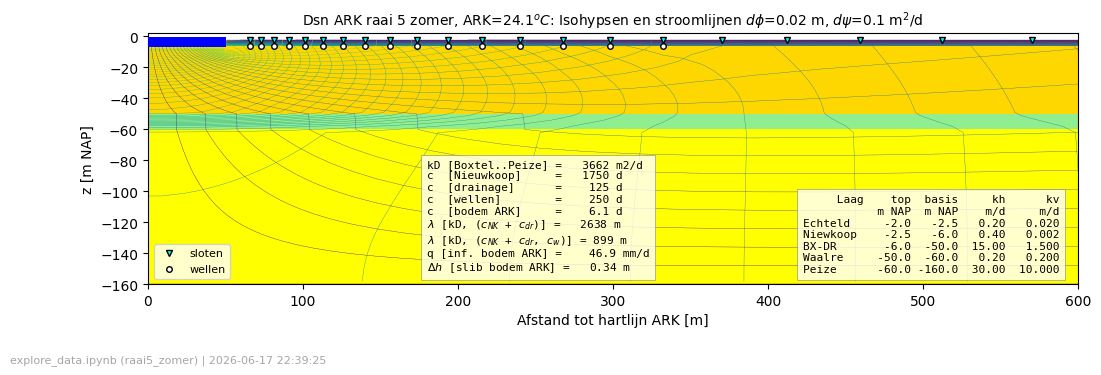

In [7]:
# --- Define funcion to fill x-section with colored patches
def get_patches(ax):
    for lg in lagen.index:
        rec = lagen.loc[lg]
        extent = (gr.x[0], gr.x[-1], rec['okLaag'], rec['bkLaag'])
        R = Rectangle((extent[0], extent[2]), extent[1] - extent[0], extent[3] - extent[2], fc=rec['fc'])
        ax.add_patch(R)
    ax.add_patch(Rectangle((0, z_ARK), b_ARK, h_ARK - z_ARK, fc='blue', zorder=4)) # ARK waterlichaam
    ax.add_patch(Rectangle((+b_ARK, z_damw), +b_damw, 0 - z_damw, fc='k', zorder=4))     # Damwand
    ax.add_patch(Rectangle((-b_ARK, z_damw), -b_damw, 0 - z_damw, fc='k', zorder=4))     # Damwand
    ax.add_patch(Rectangle((0, -z_ARK), 0, b_ARK, fc='gray', zorder=5)) # Kanaalbodem


# --- step size of isohypses and stream function lines
dphi, dpsi = 0.02, 0.1

# --- get the meta data
pbxy = Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='pbTauw')
pb_meta = pbxy.data


# --- get levels for  contouring
phi_min, phi_max = np.round(np.nanmin(out['Phi']) * 100) / 100, np.round(np.nanmax(out['Phi']) * 100) / 100
phi_levels = np.arange(phi_min, phi_max + dphi, dphi)

psi = gr.psi_row(out['Qx'], row=0)
psi_min, psi_max = np.round(np.nanmin(psi) * 100) / 100, np.round(np.nanmax(psi) * 100) / 100
psi_levels = np.arange(psi_min, psi_max + dpsi, dpsi)

# --- View window
ylim = (None, 2)
xlim = (0, 600)

# --- Plot of cross section
fig, ax = plt.subplots(figsize=(12, 4.25))

# --- Patch to show layers in colors
get_patches(ax)

# --- Contour heads and stream lines
Ch = ax.contour(gr.XM[:,0,:], gr.ZM[:,0,:], out['Phi'][:, 0, :], levels=phi_levels, linewidths=0.25)
Cp = ax.contour(gr.X[:,0,1:-1], gr.Z[:, 0, :-1], psi, levels=psi_levels, linewidths=0.25)

# --- Compute the analytical properties of this aquifer
kD, c, cGHB, cDRN = get_analytical_props(gr, lagen, GHB, DRN)
c_cov = c + cGHB
c_tot = 1/(1/c_cov + 1/cDRN)
lam_top = np.sqrt(kD * c_cov).round()
lam_tot = np.sqrt(kD * c_tot).round()

# --- Infiltration computed from Delta_h and resistance
iz_1 = gr.iz_above(z_ARK)
iz_2 = gr.iz_below(z_ARK) + 1
above_slib = (gr.ZM == gr.zm[iz_1]) & (gr.XM < b_ARK)
below_slib = (gr.ZM == gr.zm[iz_2]) & (gr.XM < b_ARK)
Delta_h = out['Phi'][above_slib] - out['Phi'][below_slib]
c_ARK_slib = gr.DZ[mask_ARK_slib] / kv[mask_ARK_slib]
Qinf_ = Delta_h / c_ARK_slib
qinf_ = Qinf_ / b_ARK

# --- Infiltration directly form the model
Qinf = out['Q'][mask_ARK]
qinf = Qinf.sum() / b_ARK

# --- GHB (sloten)
mask_GHB = gr.const(0, dtype=bool)
mask_GHB.ravel()[GHB['Ig']] = True
ax.plot(gr.XM[mask_GHB], gr.ZM[mask_GHB], 'v', lw=0.5, ms=4, mfc='aqua', mec='k', label='sloten')

# --- DRN (wellen)
mask_DRN = gr.const(0, dtype=bool)
mask_DRN.ravel()[DRN['Ig']] = True
ax.plot(gr.XM[mask_DRN], gr.ZM[mask_DRN], 'o', lw=0.5, ms=4, mfc='w', mec='k', label='wellen')


cNK = lagen.loc['NK', 'D'] / lagen.loc['NK', 'kv']
c3  = 1/(1/(cNK + cGHB) + 1 / cDRN)

prop_txt = [
    f"kD [Boxtel..Peize] = {kD:6.0f} m2/d",
    f"c  [Nieuwkoop]     = {cNK:6.0f} d",
    f"c  [drainage]      = {cGHB:6.0f} d",
    f"c  [wellen]        = {cDRN:6.0f} d",
    f"c  [bodem ARK]     = {c_ARK_slib.mean():6.1f} d",
    fr"$\lambda$ [kD, ($c_{{NK}}$ + $c_{{dr}}$)] = {lam_top:6.0f} m",
    fr"$\lambda$ [kD, ($c_{{NK}}$ + $c_{{dr}}$, $c_w$)] = {lam_tot:.0f} m",
    f"q [inf. bodem ARK] =  {qinf * 1000:6.1f} mm/d",
    fr"$\Delta h$ [slib bodem ARK] = {Delta_h.mean():6.2f} m",
]

ax.text(
    0.3, 0.04, '\n'.join(prop_txt),
    transform=ax.transAxes,
    ha='left', va='bottom',
    family='monospace',
    fontsize=8,
    bbox=dict(facecolor='white', edgecolor='0.5', linewidth=0.5, alpha=0.8)
)

ax.text(
    0.98, 0.04, '\n'.join(strat_txt),
    transform=ax.transAxes,
    ha='right', va='bottom',
    family='monospace',
    fontsize=8,
    bbox=dict(facecolor='white', edgecolor='0.5', linewidth=0.5, alpha=0.8)
)

# fig.suptitle(supttl,  fontsize=10)
ax.set_title(fr"Dsn ARK raai {case[0]} {case[1]}, ARK={temp_ARK:.1f}$^oC$: Isohypsen en stroomlijnen $d\phi$={dphi} m, $d\psi$={dpsi} m$^2$/d", fontsize=10)
ax.set_xlabel('Afstand tot hartlijn ARK [m]')
ax.set_ylabel('z [m NAP]')
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_aspect(1)
ax.legend(loc="lower left", fontsize=8)

logo(fig, NOTEBOOK_NAME + f' (raai{case[0]}_{case[1]})')

plt.show()

fname = f"xs_ark_r{case[0]}_{case[1]}.pdf"
fig.savefig(os.path.join(dirs.images, fname))

## Plot meaurements and model heads to the west of ARK for rows 4, 5, and 6

raai4, WE=W, tcol=summer, sum(mask)=1
raai4, WE=W, tcol=winter, sum(mask)=1
raai4, WE=E, tcol=summer, sum(mask)=4
raai4, WE=E, tcol=winter, sum(mask)=4
raai5, WE=W, tcol=summer, sum(mask)=3
raai5, WE=W, tcol=winter, sum(mask)=3
raai5, WE=E, tcol=summer, sum(mask)=3
raai5, WE=E, tcol=winter, sum(mask)=4
raai6, WE=W, tcol=summer, sum(mask)=3
raai6, WE=W, tcol=winter, sum(mask)=3
raai6, WE=E, tcol=summer, sum(mask)=1
raai6, WE=E, tcol=winter, sum(mask)=2


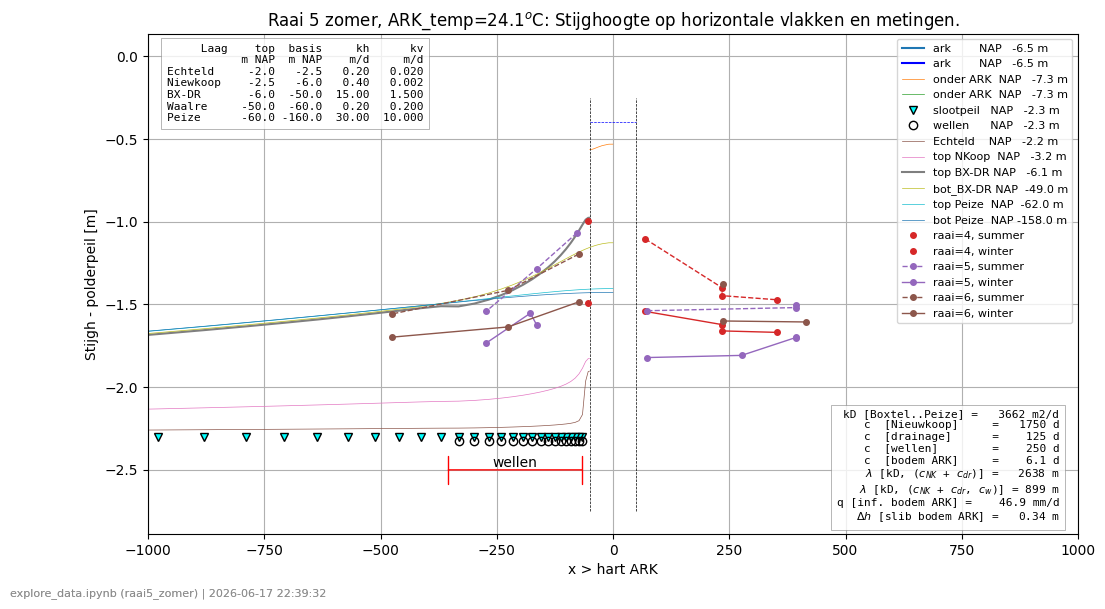

stijgh_xs_ark_raai5_zomer.pdf


In [8]:
fig, ax = plt.subplots(figsize=(12, 6.5))

# --- We want the head along the top of the first and second aquifers
iz_ARK    = gr.iz_above(z_ARK)
iz_subARK = gr.iz_below(z_ARK) # Just below the sludge layer
iz_echtel = gr.iz_below(lagen.loc['Ech', 'bkLaag'])
iz_top_NK = gr.iz_below(lagen.loc['NK', 'bkLaag'])
iz_top_BX = gr.iz_below(lagen.loc['BX', 'bkLaag'])
iz_bot_BX = gr.iz_above(lagen.loc['BX', 'okLaag'])
iz_top_Pe = gr.iz_below(lagen.loc['Pe', 'bkLaag'])
iz_bot_Pe = gr.iz_above(lagen.loc['Pe', 'okLaag'])

sloten = gr.const(0, dtype=bool)
sloten.ravel()[GHB['Ig']] = True

wellen = gr.const(0, dtype=bool)
wellen.ravel()[DRN['Ig']] = True

ark    = (gr.ZM == iz_ARK)           & (gr.XM < b_ARK)
echtel = (gr.ZM == gr.zm[iz_echtel]) & (gr.XM > b_ARK + b_damw)
top_NK = (gr.ZM == gr.zm[iz_top_NK]) & (gr.XM > b_ARK + b_damw)
top_BX = (gr.ZM == gr.zm[iz_top_BX]) & (gr.XM > b_ARK + b_damw)
subARK = (gr.ZM == gr.zm[iz_subARK]) & (gr.XM < b_ARK)
bot_BX = (gr.ZM == gr.zm[iz_bot_BX])
top_Pe = (gr.ZM == gr.zm[iz_top_Pe])
bot_Pe = (gr.ZM == gr.zm[iz_bot_Pe])

# --- setup ---
lw = 0.5
model_side = 'W'
yscale = 'linear'


ax.set_yscale(yscale)
if ax.get_yscale() == 'log':
    hpp = h_pold
else:
    hpp = 0    

if model_side == 'W':
    sign = -1

ax.plot(sign * gr.XM[ark],    out['Phi'][ark],                   -hpp, 'b', label=f'ark        NAP {gr.zm[iz_ARK   ]:6.1f} m')
ax.plot(sign * gr.XM[subARK], out['Phi'][subARK],                -hpp, lw=lw,  label=f'onder ARK  NAP {gr.zm[iz_subARK]:6.1f} m')
ax.plot(sign * gr.XM[sloten], h_pold * np.ones(len(GHB))        -hpp,  'v', lw=0.5, mfc='aqua', mec='k',  label=f'slootpeil   NAP {h_pold:6.1f} m')
ax.plot(sign * gr.XM[wellen], h_pold * np.ones(len(DRN)) - 0.025 -hpp, 'o', lw=0.5, mfc='none', mec='k',  label=f'wellen      NAP {h_pold:6.1f} m')
ax.plot(sign * gr.XM[echtel], out['Phi'][echtel]                 -hpp, lw=lw,  label=f'Echteld    NAP {gr.zm[iz_echtel]:6.1f} m')
ax.plot(sign * gr.XM[top_NK], out['Phi'][top_NK]                 -hpp, lw=lw,  label=f'top NKoop  NAP {gr.zm[iz_top_NK]:6.1f} m')
ax.plot(sign * gr.XM[top_BX], out['Phi'][top_BX]                 -hpp, lw=lw * 3,  label=f'top BX-DR NAP {gr.zm[iz_top_BX]:6.1f} m')
ax.plot(sign * gr.XM[bot_BX], out['Phi'][bot_BX]                 -hpp, lw=lw,  label=f'bot_BX-DR NAP {gr.zm[iz_bot_BX]:6.1f} m')
ax.plot(sign * gr.XM[top_Pe], out['Phi'][top_Pe]                 -hpp, lw=lw,  label=f'top Peize  NAP {gr.zm[iz_top_Pe]:6.1f} m')
ax.plot(sign * gr.XM[bot_Pe], out['Phi'][bot_Pe]                 -hpp, lw=lw,  label=f'bot Peize  NAP {gr.zm[iz_bot_Pe]:6.1f} m')

if ax.get_yscale()=='log':
    ax.set_title(f"Stijghoogte op horizontale vlakken voor raai {case[0]} {case[1]}")
    ax.set_xlabel('x > hart ARK')    
    ax.set_ylabel('Stijghoogte [m NAP]')
    ax.set_ylim(4e-2, 1e1)
else:
    ax.set_title(fr"Raai {case[0]} {case[1]}, ARK_temp={temp_ARK:.1f}$^o$C: Stijghoogte op horizontale vlakken en metingen.")
    ax.set_xlabel('x > hart ARK')
    ax.set_ylabel('Stijgh - polderpeil [m]')
    

xlim = (-b_model/10, b_model/10)
# xlim = (0, b_model)
ax.set_xlim(xlim)
ax.legend()

x1, x2, y = b_ARK + b_kade, b_ARK + b_kade + b_wellen, 2 if ax.get_yscale()=='log' else -2.5
x1 *= sign
x2 *= sign
ax.annotate('',
            xy=(x1,y),
            xytext=(x2,y),
            arrowprops=dict(arrowstyle='|-|', lw=1, color='red')
)
ax.text(0.5 * (x1 + x2), y,
        'wellen',
        ha='center', va='bottom')

ax.vlines([-b_ARK, b_ARK], ymin=-2.75, ymax=-0.25, colors=['k'], linewidths=0.5, linestyles='--')
ax.hlines([-0.4], xmin=-b_ARK, xmax=+b_ARK, colors='b', linewidths=0.5,  linestyles='--')

ax.text(0.02, 0.98, '\n'.join(strat_txt),
    transform=ax.transAxes,
    ha='left', va='top',
    family='monospace',
    fontsize=8,
    bbox=dict(facecolor='white', edgecolor='0.5', linewidth=0.5, alpha=0.8)
)

ax.text(
    0.98, 0.02, '\n'.join(prop_txt),
    transform=ax.transAxes,
    ha='right', va='bottom',
    family='monospace',
    fontsize=8,
    bbox=dict(facecolor='white', edgecolor='0.5', linewidth=0.5, alpha=0.8)
)

ax.grid(True)
ax.legend(loc='upper right', fontsize=8)

logo(fig, NOTEBOOK_NAME + f' (raai{case[0]}_{case[1]})')

# === Add heads measured in cross sections perpendicular to the ARK
if True:
    if case[1] == 'winter':
        pass
    raaien = [4, 5, 6]
        
    for raai in np.unique(pb_meta['raai']):
        if raai not in raaien:
            continue
        for WE in ['W', 'E']:                    
            for tcol in ['summer', 'winter']:
                mask = (pb_meta['raai'] == raai) & (pb_meta['WE'] == WE) & (pb_meta[tcol] != 0)
                print(f"raai{raai}, WE={WE}, tcol={tcol}, sum(mask)={np.sum(mask)}")
                n = np.sum(mask)
                if n < 1:
                    continue
                x = pb_meta.loc[mask, 'dist'].values
                y = pb_meta.loc[mask, tcol].values
                
                if WE == 'W':
                    sign = -1  # For now all on the positive x-axis
                    label=f"raai={raai}, {tcol}"                
                else:
                    sign = +1
                    label=""                
                    
                if tcol == 'summer':
                    ls = '--'
                else:
                    ls = '-'
                                
                    
                if n == 1:
                    ax.plot(sign * x, y, 'o', ms=4, color=raai_colors[raai - 1], label=label)
                    pass
                else:
                    if tcol == tcol[1]:
                        lw = 2
                    else:
                        lw = 1
                    ix = np.argsort(x)
                    ax.plot(sign * x[ix], y[ix], marker='o', ms=4, ls=ls, color=raai_colors[raai - 1], lw=lw, label=label)


ax.grid(True)
ax.legend(loc='upper right', fontsize=8)

logo(fig, NOTEBOOK_NAME + f' (raai{case[0]}_{case[1]})')

plt.show()

if ax.get_yscale() == 'log':
    fname = f"stijgh_log_xs_ark_raai{case[0]}_{case[1]}.pdf"
else:
    fname = f"stijgh_xs_ark_raai{case[0]}_{case[1]}.pdf"
fig.savefig(os.path.join(dirs.images, fname))


print(fname)
fig.savefig(os.path.join(dirs.images, fname))


In [21]:
out['Phi'][mask_boxt] // gr.nx
# out['Phi'][mask_ARK_slib]
# gr.NOD[mask_ARK_slib] // gr.nx
gr.iz_below(lagen.loc['BX', 'bkLaag'])
gr.iz_below(z_ARK)
out['Phi'][gr.iz_below(z_ARK)], out['Phi'][gr.iz_below(lagen.loc['BX', 'bkLaag'])]


(array([[-0.53136814, -0.53151968, -0.54017527, -0.54965229, -0.55658354,
         -0.56062067, -0.56265214, -0.56358882, -0.56400042, -0.56417688,
         -0.56426393, -0.56430586,         nan, -0.97286373, -0.97345528,
         -0.98541345, -1.01325295, -1.04866322, -1.08583171, -1.12365142,
         -1.16153422, -1.19916219, -1.23634958, -1.27296075, -1.30885867,
         -1.34386806, -1.37774352, -1.41013439, -1.44053522, -1.46819309,
         -1.49187438, -1.50901656, -1.51024504, -1.52203801, -1.53711197,
         -1.55385124, -1.57177818, -1.59079022, -1.61093042, -1.63229551,
         -1.65499472, -1.67912853, -1.70477518, -1.73198024, -1.76074821,
         -1.79103596, -1.82274785, -1.85573223, -1.88977911, -1.92461907,
         -1.95992387, -1.99530934, -2.03034144, -2.06454626, -2.09742403,
         -2.128467  , -2.15717955, -2.18309804, -2.20580542, -2.22493325,
         -2.24013864, -2.25103498, -2.25703373, -2.25703681]]),
 array([[-0.4       , -0.4       , -0.4       , 

In [ ]:
pb = pd.DataFrame()
pb_meta = pb_meta.astype(dtype={'raai':int, 'dist':float, 'summer':float, 'winter':float, 'ZP':float, 'WP':float})
for raai in range(14):
    pb = pd.concat((
        pb, pb_meta[['raai', 'dist', 'summer', 'winter', 'ZP', 'WP']][(pb_meta['raai']==raai) & (pb_meta['dist'] < 200.) & (pb_meta['WE']=='W') & (pb_meta['summer'] !=0.) & (pb_meta['winter'] !=0.)])
    )
pb['Z-W']=pb['summer'] - pb['winter']
pb['sum'] = np.nan

,raai,dist,summer,winter,ZP,WP,Z-W
name,,,,,,,
101,1,59.5,-1.692,-1.780,-2.30,-2.00,0.088
201,2,47.6,-1.481,-1.684,-2.30,-2.00,0.203
302,3,58.2,-1.235,-1.556,-2.30,-2.30,0.321
406,4,53.0,-0.998,-1.490,-2.30,-2.30,0.492
505,5,164.5,-1.285,-1.622,-2.30,-2.30,0.337
603,6,73.9,-1.196,-1.485,-2.60,-2.60,0.289
702,7,72.5,-1.036,-1.424,-2.60,-2.60,0.388
802,8,89.0,-1.341,-1.524,-2.33,-2.33,0.183
902,9,119.5,-1.395,-1.551,-2.25,-2.25,0.156


  name  h_ARK    hTr     hp      T Tr     mu_rat  q_rat    hT1    hT2     hT hT-hT2
   101 -0.400 -1.780 -2.000  24.10  3.700  0.584  1.560 -1.657 -1.657 -1.692 -0.035
   201 -0.400 -1.684 -2.000  24.10  3.700  0.584  1.502 -1.525 -1.525 -1.481  0.044
   302 -0.400 -1.556 -2.300  24.10  3.700  0.584  1.339 -1.304 -1.304 -1.235  0.069
   406 -0.400 -1.490 -2.300  24.10  3.700  0.584  1.314 -1.236 -1.236 -0.998  0.238
   505 -0.400 -1.622 -2.300  24.10  3.700  0.584  1.366 -1.374 -1.374 -1.285  0.089
   603 -0.400 -1.485 -2.600  24.10  3.700  0.584  1.258 -1.197 -1.197 -1.196  0.001
   702 -0.400 -1.424 -2.600  24.10  3.700  0.584  1.240 -1.141 -1.141 -1.036  0.105
   802 -0.400 -1.524 -2.330  24.10  3.700  0.584  1.320 -1.266 -1.266 -1.341 -0.075
   902 -0.400 -1.551 -2.250  24.10  3.700  0.584  1.350 -1.307 -1.307 -1.395 -0.088
   903 -0.400 -1.531 -2.250  24.10  3.700  0.584  1.342 -1.285 -1.285 -1.325 -0.040
  1003 -0.400 -1.423 -2.300  24.10  3.700  0.584  1.289 -1.170 -1.170 -1.193

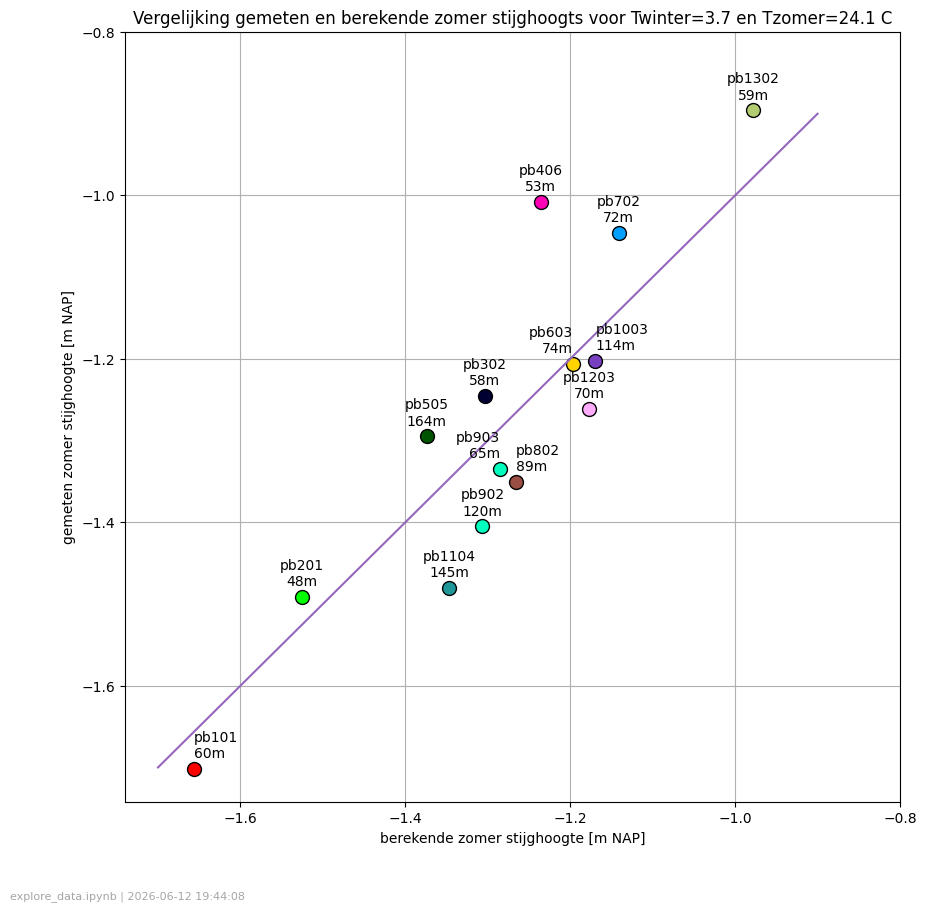

In [113]:
Tr, T = [8.5, 18.8]
Tr, T = [3.7, 24.1]
mu_ratio = muT_mu10C(T) / muT_mu10C(Tr)
h_ARK = -0.4

fig, ax = plt.subplots(figsize=(10., 10.))
ax.set_title(f"Vergelijking gemeten en berekende zomer stijghoogts voor Twinter={Tr} en Tzomer={T} C")
ax.set_ylabel("gemeten zomer stijghoogte [m NAP]")
ax.set_xlabel("berekende zomer stijghoogte [m NAP]")

pb['ha'] = 'center'
pb.loc[[603, 903], 'ha'] = 'right'
pb.loc[[101, 802, 1003], 'ha'] = 'left'

print(f"{'name':>6} {'h_ARK':>6} {'hTr':>6} {'hp':>6} {'T':>6} {'Tr':6} {'mu_rat':>6} {'q_rat':>6} {'hT1':>6} {'hT2':>6} {'hT':>6} {'hT-hT2'}")
for i, name in enumerate(pb.index):
    rec = pb.loc[name]
    raai = int(rec['raai'])    
    hp = rec['WP']
    hTr = rec['winter']
    hT  = rec['summer']
    dist = rec['dist']
    q_ratio = (h_ARK - hp) / ((h_ARK - hTr) * mu_ratio + (hTr - hp))
    hT1 = hp + q_ratio * (hTr - hp)
    hT2 = hp + (h_ARK - hp) / ((h_ARK - hTr)/(hTr - hp) * mu_ratio + 1)
    pb.loc[name, 'sum'] = hT2.round(3)
    print(f"{name:>6} {h_ARK:6.3f} {hTr:6.3f} {hp:6.3f} {T:6.2f} {Tr:6.3f} {mu_ratio:6.3f} {q_ratio:6.3f} {hT1:6.3f} {hT2:6.3f} {hT:6.3f} {hT - hT2:6.3f}")
    
    ax.plot(hT2, hT - 0.01, 'o', mfc=leg_colors[raai], ms=10, mec='k', label='name')
    ax.text(hT2, hT, f"pb{name}\n{dist:.0f}m", ha=rec['ha'], va='bottom')

ax.plot([-1.7, -0.9], [-1.7, -0.9])
ax.set_xlim(None, -0.8)
ax.set_ylim(None, -0.8)
ax.grid()

logo(fig, NOTEBOOK_NAME)

fig.savefig(os.path.join(dirs.images, f'ber_vs_gem_zomer_stijghoogen_T{Tr:.0f}_{T:.0f}.pdf'))

plt.show()


In [122]:
((h_ARK - pb['summer'])/0.05), ((h_ARK - pb['winter']) / 0.025)
muT_mu10C(18.8) * 6, muT_mu10C(8.5) * 6

(np.float64(4.7561545268504215), np.float64(6.242367198818834))

## Vergelijk stijghoogte Boxtel in het model met analytische berekening om de flux te checken

lam_tot=899.0 lam_top=2638.0
Q=2.37, q=0.047405


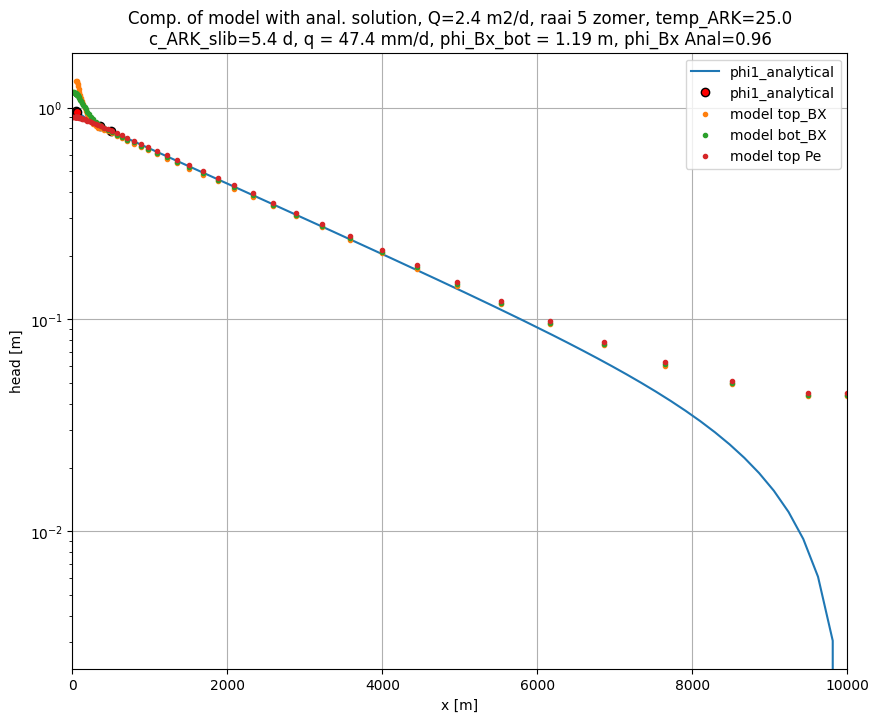

In [25]:
print(f"lam_tot={lam_tot} lam_top={lam_top}")

# --- Collect the data for the analytic comparison

# --- Totale instroom vanuit ARK en infiltratieflux
Q = out['Q'][IBOUND==-1].sum()
q = Q / b_ARK
print(f"Q={Q:.2f}, q={q:4f}")

# ---- Stijghoogte basis boxtel ten opzichte van polderpeil
phiBX = out['Phi'][bot_BX] - h_pold
xBX = gr.XM[bot_BX]

# --- Berekening met nsec1 ----
# --- Secties baseren op 4 punten
Xp = np.array([b_ARK,
               b_ARK + b_kade,
               b_ARK + b_kade + b_wellen,
               500.,
               b_model])

# --- Randvoorwaarden
Qp = [-Q, 0., 0., 0., 0.]
Phi = [np.nan, h_pold]

L = np.diff(Xp)
h = np.ones_like(L) * h_pold
c = np.array([lam_tot, # --- met wellen
              lam_tot, # --- met wellen
              lam_top, # --- zonder wellen
              lam_top]) ** 2 / kD

# --- the nsec1 model
nsec1 = Nsec1(L=L, kD=np.array([kD, kD, kD, kD]), c=c, X0=b_ARK)

# --- Resulaten
outx = nsec1.simulate(Phi=Phi, Q=Qp, h=h)
outp = nsec1.simulate(Phi=Phi, Q=Qp, h=h, x=nsec1.X)

# --- Plotten
fig, ax = plt.subplots(figsize=(10, 8))
# ---- De analytische oplossing van nsec1
ax.plot(nsec1.x, outx['phi'] - h_pold, label='phi1_analytical')
ax.plot(Xp, outp['phi'] - h_pold, 'ro', mec='k',  label='phi1_analytical')

# --- Model resultaten
ax.plot(gr.XM[top_BX], out['Phi'][top_BX] - h_pold, '.', label='model top_BX')
ax.plot(gr.XM[bot_BX], out['Phi'][bot_BX] - h_pold, '.', label='model bot_BX')
ax.plot(gr.XM[top_Pe], out['Phi'][top_Pe] - h_pold, '.', label='model top Pe')

tln = f"c_ARK_slib={c_ARK_slib.mean():.1f} d, q = {q*1e3:.1f} mm/d, phi_Bx_bot = {out['Phi'][bot_BX][0] - h_pold:.2f} m, phi_Bx Anal={outp['phi'][0] - h_pold:.2f}"
# --- Afronding ---
ax.grid(True)
ax.set_title(f"Comp. of model with anal. solution, Q={Q:.2} m2/d, raai {case[0]} {case[1]}, temp_ARK={temp_ARK}" + "\n" + tln)

ax.set_ylabel('head [m]')
ax.set_xlabel('x [m]')
ax.set_yscale('log')
ax.set_xlim(0, 10000)
ax.set_ylim(None, None)
ax.legend()

# Plot all  summer and winter data 

raai1, WE=W, tcol=summer, sum(mask)=1
raai1, WE=W, tcol=winter, sum(mask)=1
raai1, WE=E, tcol=summer, sum(mask)=1
raai1, WE=E, tcol=winter, sum(mask)=1
raai2, WE=W, tcol=summer, sum(mask)=1
raai2, WE=W, tcol=winter, sum(mask)=1
raai2, WE=E, tcol=summer, sum(mask)=1
raai2, WE=E, tcol=winter, sum(mask)=1
raai3, WE=W, tcol=summer, sum(mask)=1
raai3, WE=W, tcol=winter, sum(mask)=2
raai3, WE=E, tcol=summer, sum(mask)=2
raai3, WE=E, tcol=winter, sum(mask)=0
raai4, WE=W, tcol=summer, sum(mask)=1
raai4, WE=W, tcol=winter, sum(mask)=2
raai4, WE=E, tcol=summer, sum(mask)=4
raai4, WE=E, tcol=winter, sum(mask)=6
raai5, WE=W, tcol=summer, sum(mask)=3
raai5, WE=W, tcol=winter, sum(mask)=4
raai5, WE=E, tcol=summer, sum(mask)=3
raai5, WE=E, tcol=winter, sum(mask)=6
raai6, WE=W, tcol=summer, sum(mask)=3
raai6, WE=W, tcol=winter, sum(mask)=3
raai6, WE=E, tcol=summer, sum(mask)=1
raai6, WE=E, tcol=winter, sum(mask)=2
raai7, WE=W, tcol=summer, sum(mask)=2
raai7, WE=W, tcol=winter, sum(mask)=2
raai7, WE=E,

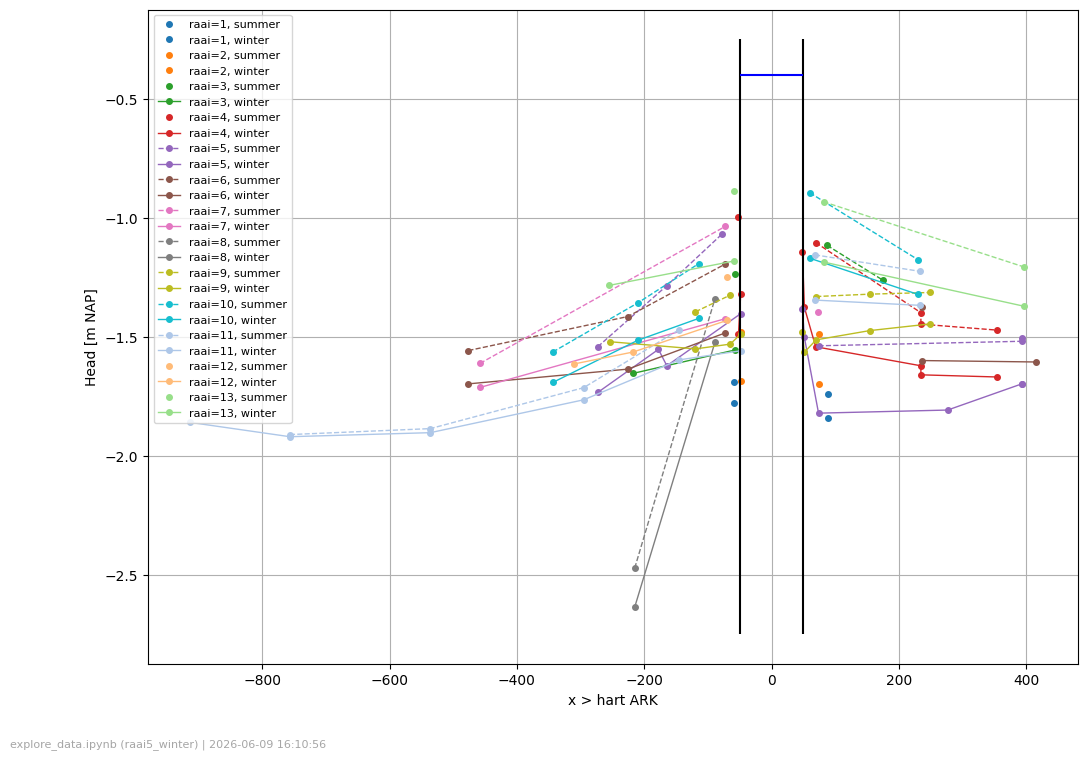

In [190]:
fig, ax = plt.subplots(figsize=(12, 8.5))

ax.set_xlabel('x > hart ARK')
ax.set_ylabel('Head [m NAP]')

# === Add heads measured in cross sections perpendicular to the ARK

for raai in np.unique(pb_meta['raai']):
    # if raai not in [case[0]]: # [4, 5, 6, 11]:
    #    continue
    for WE in ['W', 'E']:
        for tcol in ['summer', 'winter']:
            mask = (pb_meta['raai'] == raai) & (pb_meta['WE'] == WE) & (pb_meta[tcol] != 0)
            print(f"raai{raai}, WE={WE}, tcol={tcol}, sum(mask)={np.sum(mask)}")
            n = np.sum(mask)
            if n < 1:
                continue
            x = pb_meta.loc[mask, 'dist'].values
            y = pb_meta.loc[mask, tcol].values
            
            if WE == 'W':
                x = -x  # For now all on the positive x-axis
                label=f"raai={raai}, {tcol}"                
            else:
                label=""                
                
            if tcol == 'summer':
                ls = '--'
            else:
                ls = '-'
                            
                
            if n == 1:
                ax.plot(x, y, 'o', ms=4, color=raai_colors[raai - 1], label=label)
                pass
            else:
                if tcol == tcol[1]:
                    lw = 2
                else:
                    lw = 1
                ix = np.argsort(x)
                ax.plot(x[ix], y[ix], marker='o', ms=4, ls=ls, color=raai_colors[raai - 1], lw=lw, label=label)

ax.vlines([-b_ARK, b_ARK], ymin=-2.75, ymax=-0.25, colors=['k'])
ax.hlines([-0.4], xmin=-b_ARK, xmax=+b_ARK, colors='b')

ax.grid(True)
ax.legend(fontsize=8)

logo(fig, NOTEBOOK_NAME + f' (raai{case[0]}_{case[1]})')

plt.show()

fname = "stijgh_xs_ark_gemeten.pdf"
fig.savefig(os.path.join(dirs.images, fname))


# Distance wellen to ARK hartlijn

First get the meta data for the piezometers, which contains the row (raai) info.

Then define the y-range pertaining to each raai yielding a DataFrame with raai and y_mean, y_max and y_min
coordinates.

Then get the wellen in a DataFrame.

Add the column raai to it. For each point the raai is determined from the coordinate falling in a raai-range in the raaien DataFrame.

Pandas as a special trick for this, provide by chatgpt.

In [ ]:
# --- Get the wellen
wellen_ = picklefrom(os.path.join(dirs.data, "wellen.pkl"))
wellen = pd.DataFrame(wellen_)
wellen.columns = ['x', 'y']
wellen.index.name = 'id'
wellen

# --- Add distance to ARK and xhit, yhit (perpendicular lines)
dist, pnts_hit = point_polyline_distance(wellen_, hartlijn_ARK)
wellen['dist'] = np.round(dist, 1)
wellen['xhit'] = pnts_hit.T[0].round(1)
wellen['yhit'] = pnts_hit.T[1].round(1)
wellen

In [ ]:
# --- get the meta data
pbxy = Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='pbTauw')
pb_meta = pbxy.data

# --- Generate the raaien DataFrame
Y = {}
# --- Get the existing raaien from the pd_meta DataFrame
for raai in np.unique(pb_meta['raai'].values):
    # --- the mean y for all piezometers belonging to a raai
    y = pb_meta.loc[pb_meta['raai']==raai, 'y'].mean()
    Y[int(raai)] = {'mean':float(y.mean().round())} 
    
# --- Add a virtual raai above and below the  existing ones
Y[ 0] = {'mean':Y[ 1]['mean'] + 250}
Y[14] = {'mean':Y[13]['mean'] - 250}

# --- Reorder the keys
for k in sorted(Y.keys()):
    Y[k] = Y.pop(k)
 
 # --- Get the min and max y for all raaien except the virtual ones
for k in list(Y.keys())[1:-1]:
    Y[k]['max'] =  (Y[k]['mean'] + Y[k-1]['mean']) / 2
    Y[k]['min']  = (Y[k]['mean'] + Y[k+1]['mean']) / 2

# --- Print the results except the virtual ones
for k in list(Y.keys())[1:-1]:
    # print(f"{k},{Y[k]['mean']},{Y[k]['max']},{Y[k]['min']}")
    pass
    
    
# --- Generate the DataFrame
raaien = pd.DataFrame(Y).T
raaien.index.name = "raai"

# --- Remove the virtual raaien
raaien = raaien.loc[raaien.index[1:-1]]
raaien

In [ ]:
import pandas as pd

# Create intervals [min, max)
intervals = pd.IntervalIndex.from_arrays(
    raaien['min'],
    raaien['max'],
    closed='left'
)

# Find the interval containing each y coordinate
wellen['raai'] = raaien.index[intervals.get_indexer(wellen['y'])]

# --- Sort wellen by 'raai' and then by 'dist'
wellen = wellen.sort_values(['raai', 'dist'])

# --- Redifine the index
wellen.index = np.arange(len(wellen))
wellen

pickleto(wellen, os.path.join(dirs.data, "wellen_df.pkl"))

In [ ]:
ok_NK = lagen.loc['NK', 'okLaag']
iz = np.searchsorted(-gr.z, -ok_NK)
b_wellen = 300. # Width the area next to the canal with the bulk of the wellen
mask_wellen = (gr.ZM == gr.zm[iz]) & (gr.XM > b_ARK + 10) & (gr.XM < b_ARK + b_wellen)

gr.XM[mask_wellen]

len(wellen)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
wellen.hist('dist', ax=ax)
ax.set_title("Afstand wellen tot midden ARK [m]")
ax.set_xlabel("Afstand tot hartlijn ARK")
ax.set_ylabel("Aantal wellen in 'Beemster e.a. (2022)'")
ax.grid(True)
logo(fig, NOTEBOOK_NAME)
# fig.savefig(os.path.join(dirs.images, "hist_afstand_wellen_tot_ARK.pdf"))

Ig = gr.NOD[mask_wellen]
gr.ZM[mask_wellen]
